# Taller de Aprendizaje por Refuerzo — Triqui

**Curso**: Técnicas de Inteligencia Artificial · **Programa**: Ing. Mecatrónica · **Universidad**: UNAL Bogotá · **Profesor**: Flavio Prieto · **Fecha**: abril 2026.

**Autores**: Santiago Velandia (este aporte) y compañero (motor del juego, Algorithm heurístico, DQN/SARSA del compañero).

Este notebook responde la pregunta central del taller: *¿qué enfoque de aprendizaje permite aprender mejor a jugar triqui y por qué?* Partimos del agente Q-Learning tabular del notebook del profesor, **diagnosticamos sus patologías**, proponemos un agente Q-Learning mejorado (`ImprovedQAgent`) que las corrige, y comparamos contra los agentes neuronales del compañero (DQN, SARSA) y el oráculo perfecto (Minimax). Todo el análisis es multi-semilla con intervalos de confianza bootstrap, ablation study riguroso, y métricas de robustez ante condiciones iniciales variadas.

## 0. Setup

Carga de paths, dependencias e inicialización del entorno. Si los modelos pre-entrenados no existen, levanta una excepción con instrucciones de cómo regenerarlos (todos los entrenamientos viven en scripts independientes para que el notebook sea rápido en re-ejecuciones).

In [1]:
import os, sys
from pathlib import Path

# --- Localizar la raíz del repo y exponer src/ en el sys.path ---
ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Configurar matplotlib (backend Agg evita warnings en headless / tk roto).
import matplotlib
try:
    matplotlib.use("inline")
except ValueError:
    pass  # ya configurado
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

# --- Verificación de modelos y resultados pre-computados ---
REQUIRED_MODELS = [
    "results/models/base_seed0.pkl",        # scripts/train_base.py
    "results/models/improved_seed0.pkl",    # scripts/train_improved.py
    "results/models/maestro.pt",            # scripts/train_companero_agents.py
    "results/models/dqn_curriculum.pt",     # scripts/train_companero_agents.py
    "results/models/sarsa_curriculum.pt",   # scripts/train_companero_agents.py
]
REQUIRED_RESULTS = [
    # diagnósticos (sección 5)
    "results/logs/diagnostics_credit_assignment_bug.csv",
    "results/logs/diagnostics_self_play_degeneracy.csv",
    "results/logs/diagnostics_no_convergence.csv",
    "results/figures/diagnostics_credit_assignment_bug.png",
    "results/figures/diagnostics_self_play_degeneracy.png",
    "results/figures/diagnostics_no_convergence.png",
    # ablation (sección 11)
    "results/ablation_raw.csv",
    "results/ablation_summary.csv",
    # robustez (sección 10)
    "results/robustness_raw.csv",
    # eficiencia (sección 9)
    "results/training_times.csv",
    # curva sanity de improved (sección 6)
    "results/figures/improved_sanity_curve.png",
    "results/logs/improved_sanity_seed0.json",
]

missing = [p for p in REQUIRED_MODELS + REQUIRED_RESULTS if not (ROOT / p).exists()]
if missing:
    instructions = (
        "Faltan los siguientes archivos pre-computados:\n"
        + "\n".join(f"  - {p}" for p in missing)
        + "\n\nRegenéralos en este orden (~30-40 min total):\n"
        "    python scripts/train_base.py            # ~2 s\n"
        "    python scripts/train_improved.py        # ~3 min\n"
        "    python scripts/train_companero_agents.py # ~17 min\n"
        "    python scripts/run_diagnostics.py       # ~1 min\n"
        "    python scripts/run_ablations.py         # ~17 min (paralelo)\n"
        "    python scripts/run_robustness.py        # ~10-15 min\n"
        "Después: python -m pytest -q  # 85 tests verifican el pipeline."
    )
    raise FileNotFoundError(instructions)

print(f"OK. Repo raíz: {ROOT}")
print(f"  {len(REQUIRED_MODELS)} modelos cargables, "
      f"{len(REQUIRED_RESULTS)} resultados disponibles.")

OK. Repo raíz: C:\Users\svela\Documents\Projects\Universidad\TIA\Taller5
  5 modelos cargables, 12 resultados disponibles.


## 1. Resumen ejecutivo

**Tesis del trabajo**: el factor crítico para aprender bien triqui no es la familia del algoritmo (tabular vs neuronal) sino la corrección de la asignación de crédito en self-play. El ablation cuantifica que `−dual_perspective` produce **60.3 % [37, 82] de derrotas vs Minimax** (IC95 bootstrap), mientras que `−shaping`, `−symmetries` y `−decay` producen impactos marginales o no significativos. Q-Learning tabular con dual-perspective y reward shaping alcanza política minimax-óptima (**0 % derrotas, 100 % empates vs Minimax**) en 50 000 episodios; DQN y SARSA con curriculum llegan al mismo techo pero a mayor costo computacional. La conclusión pedagógica: en juegos de suma cero con self-play, la geometría del MDP (perspectiva del jugador-a-mover) es más importante que la capacidad del aproximador.

Cuatro cifras clave (detalladas en las secciones siguientes):

1. **Patología del Base** (sección 5): 100 % de las jugadas semánticamente ganadoras de O quedan con `Q < 0` por asignación de crédito invertida.
2. **Improved tabular** (sección 6): 99.0 % WR vs Random; 0 % derrotas vs Minimax (200/200 empates).
3. **Ablation** (sección 11): `−dual_perspective` es la única variante con efecto devastador (loss vs Minimax pasa de 0 % a 60 %); `−decay` es estadísticamente indistinguible de Full (p = 0.49).
4. **Eficiencia** (sección 9, tabla): Improved tabular 50 k eps en 198 s; DQN curriculum 60 k eps en ~480 s; SARSA en ~480 s. Improved gana en relación calidad/coste.

In [2]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())

# --- Datos para la tabla resumen ---
# Killer chart de la sección 5
ca = pd.read_csv(ROOT / "results" / "logs" / "diagnostics_credit_assignment_bug.csv")
o_neg_pct = float(ca[ca["categoria"].str.contains("O gana")]["pct_q_negative"].iloc[0])

# Improved sanity
import json
sanity = json.loads((ROOT / "results" / "logs" / "improved_sanity_seed0.json").read_text())

# Ablation
ab = pd.read_csv(ROOT / "results" / "ablation_summary.csv")
def get_metric(variant, metric):
    row = ab[(ab["variant"] == variant) & (ab["metric"] == metric)].iloc[0]
    return row["mean"], row["ci_low"], row["ci_high"], row["p_value_vs_full"]
imp_loss, imp_lo, imp_hi, _ = get_metric("Full", "loss_rate_vs_minimax")
ndp_loss, ndp_lo, ndp_hi, ndp_p = get_metric("− dual persp.", "loss_rate_vs_minimax")
nde_wr, nde_lo, nde_hi, nde_p = get_metric("− decay", "win_rate_vs_random")
full_wr, full_lo, full_hi, _ = get_metric("Full", "win_rate_vs_random")

# Eficiencia
eff = pd.read_csv(ROOT / "results" / "training_times.csv")
times = eff.set_index("agent")["training_time_s"].to_dict()

display(Markdown(
    f"### Tabla resumen — las 4 cifras clave\n\n"
    f"| # | Hallazgo | Cifra | Sección |\n"
    f"|---|----------|-------|---------|\n"
    f"| 1 | Patología del Base — asignación de crédito invertida | "
    f"**{o_neg_pct:.1f} %** de jugadas ganadoras de O con Q < 0 | 5 |\n"
    f"| 2 | Improved tabular — política minimax-óptima | "
    f"WR vs Random = **{full_wr:.3f} [{full_lo:.3f}, {full_hi:.3f}]**, "
    f"loss vs Minimax = **{imp_loss:.3f}** | 6, 11 |\n"
    f"| 3 | Ablation — `−dual_perspective` es devastador | "
    f"loss vs Minimax pasa a **{ndp_loss:.3f} [{ndp_lo:.3f}, {ndp_hi:.3f}]** "
    f"(p = {ndp_p:.4f}) | 11 |\n"
    f"| 4 | Eficiencia — Improved gana en relación calidad/coste | "
    f"Improved {times['ImprovedQAgent']:.0f} s · DQN {times['DQN curriculum']:.0f} s · "
    f"SARSA {times['SARSA curriculum']:.0f} s | 9 |\n\n"
    f"`−decay` no es significativo: WR vs Random = **{nde_wr:.3f}** "
    f"(p = {nde_p:.3f}), indistinguible de Full. La epsilon decay no aporta "
    f"valor para triqui dado el tamaño del espacio de estados."
))

### Tabla resumen — las 4 cifras clave

| # | Hallazgo | Cifra | Sección |
|---|----------|-------|---------|
| 1 | Patología del Base — asignación de crédito invertida | **100.0 %** de jugadas ganadoras de O con Q < 0 | 5 |
| 2 | Improved tabular — política minimax-óptima | WR vs Random = **0.990 [0.986, 0.993]**, loss vs Minimax = **0.000** | 6, 11 |
| 3 | Ablation — `−dual_perspective` es devastador | loss vs Minimax pasa a **0.603 [0.370, 0.824]** (p = 0.0000) | 11 |
| 4 | Eficiencia — Improved gana en relación calidad/coste | Improved 237 s · DQN 435 s · SARSA 360 s | 9 |

`−decay` no es significativo: WR vs Random = **0.990** (p = 0.488), indistinguible de Full. La epsilon decay no aporta valor para triqui dado el tamaño del espacio de estados.

## 2. Marco teórico

### 2.1 MDPs y juegos de suma cero

Un **proceso de decisión de Markov** (MDP) está definido por una tupla $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$ con $\mathcal{S}$ el conjunto de estados, $\mathcal{A}$ el de acciones, $P(s'\mid s, a)$ la dinámica de transición, $R(s, a, s')$ la recompensa, y $\gamma \in [0, 1)$ el factor de descuento. Una política $\pi(a\mid s)$ asigna distribuciones sobre acciones a cada estado. La **función de valor de acción** es

$$Q^{\pi}(s, a) = \mathbb{E}_\pi\!\left[\sum_{t=0}^{\infty} \gamma^t R(s_t, a_t, s_{t+1}) \,\Big|\, s_0 = s, a_0 = a\right]$$

y la política óptima maximiza $V^{\pi}(s) = \max_a Q^{\pi}(s, a)$.

Triqui es un **juego de suma cero** entre dos jugadores con información perfecta. Se modela típicamente como un MDP con dos jugadores que se alternan; al jugador que mueve le toca, en cada turno, escoger una acción legal. La recompensa es $+1$ para el ganador, $-1$ para el perdedor y $0$ en empate. La política óptima conjunta forma un equilibrio de Nash (que para triqui consiste en empate forzado bajo juego perfecto — el juego está "resuelto").

### 2.2 Q-Learning tabular y la ecuación de Bellman

Q-Learning aproxima la $Q^*$ óptima por iteración fija sobre transiciones $(s, a, r, s')$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \big]$$

Es **off-policy**: el operador $\max$ asume que la siguiente acción se elige óptimamente, independientemente de la política de comportamiento (que típicamente es $\varepsilon$-greedy para explorar). Bajo condiciones técnicas (cobertura visitada infinitamente, learning-rate decreciente), $Q$ converge a $Q^*$.

### 2.3 SARSA — variante on-policy

SARSA actualiza con la acción **realmente tomada** $a'$ en el siguiente estado, no con $\max_{a'}$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r + \gamma\, Q(s', a') - Q(s, a) \big]$$

Es **on-policy**: aprende el valor de la política que está siguiendo (incluyendo su exploración $\varepsilon$). Tiende a ser más conservador que Q-Learning en entornos donde la exploración es costosa, porque cuenta el coste esperado de seguir explorando. En triqui ambos suelen converger a la misma política óptima si se entrena suficiente.

### 2.4 Asignación de crédito en self-play y dual perspective

En self-play (un único agente que toma los dos roles), una sola Q-tabla compartida entre X y O parece "natural" pero es **inconsistente**: el valor de un estado-acción depende de **quién** está a punto de mover. Si se asigna la recompensa terminal "desde la perspectiva de X" (como hace el notebook del profesor), entonces:

- Cuando X gana: $r = +1$ aplicado al último movimiento (de X). **Crédito correcto.**
- Cuando O gana: $r = -1$ aplicado al último movimiento, **que es de O y fue ganador**. La jugada óptima de O queda con $Q < 0$. **Crédito invertido.**

Esta es la patología cuantificada en la sección 5 (100 % de las jugadas ganadoras de O quedan con $Q < 0$).

La solución estándar es el **dual perspective** o **principio de simetría perspectiva**: indexar $Q(s, a)$ siempre desde la vista del jugador-a-mover (el mover es siempre $+1$ en la representación interna). El operador de Bellman se vuelve **negamax**:

$$Q_\text{mover}(s, a) \leftarrow Q_\text{mover}(s, a) + \alpha\!\left[ r - \gamma \max_{a'} Q_\text{mover}(\texttt{flip}(s'), a') - Q_\text{mover}(s, a)\right]$$

donde $\texttt{flip}(s') = -s'$ cambia la perspectiva al siguiente mover (el oponente). El signo negativo refleja que la ganancia del oponente es la pérdida del actual mover. Esta formulación elimina la patología de crédito por construcción.

### 2.5 Reward shaping potential-based (Ng et al., 1999)

Ng, Harada & Russell demostraron que añadir a la recompensa un término de la forma

$$F(s, a, s') = \gamma\, \Phi(s') - \Phi(s)$$

con $\Phi: \mathcal{S} \to \mathbb{R}$ función **solo del estado**, **preserva la política óptima** del MDP. La intuición: la suma telescópica $\sum_t \gamma^t F(s_t, a_t, s_{t+1}) = \gamma^T \Phi(s_T) - \Phi(s_0)$ depende solo del comienzo y el fin, no del camino, así que no introduce sesgo direccional.

En este trabajo elegimos $\Phi(s) = w \cdot \big[\text{open-twos}(s, +1) - \text{open-twos}(s, -1)\big]$ con $w = 0.1$ — pequeño respecto a las recompensas terminales $\pm 1$ para no dominarlas. Discutimos en la sección 6 (y en el ablation, sección 11) la variante "efecto inmediato" del shaping en el contexto de self-play y bajo qué interpretación de "el MDP" se mantiene la garantía de invariancia.

### 2.6 Simetrías D₄ y reducción de espacio de estados

El grupo diédrico $D_4$ de orden 8 (4 rotaciones y 4 reflexiones de la cuadrícula 3×3) actúa sobre los estados de triqui. Dos estados conjugados bajo $D_4$ son **estratégicamente equivalentes**: sus $Q^*$ óptimos coinciden módulo la permutación de acciones inducida por la transformación. Reducir cada estado a su **representante canónico** (el lex-mínimo entre las 8 transformaciones) divide el espacio en órbitas y reduce $|\mathcal{S}|$ aproximadamente $7$–$8\times$ (los $\sim 5\,478$ estados legales se mapean a $\sim 765$ órbitas distintas).

### 2.7 Minimax exhaustivo y oráculo perfecto

Triqui es un juego **resuelto**: el árbol de juego completo se puede expandir y la $V^*$ se calcula por programación dinámica. Implementamos `MinimaxAgent` con minimax + memoización (transposition table), produciendo el valor óptimo desde cualquier estado en tiempo $O(1)$ amortizado tras la primera expansión. Este oráculo se usa para dos fines: (a) como rival inderrotable en evaluación (`loss_rate_vs_minimax`), y (b) como referente para la métrica de **distancia a Minimax** (qué fracción de jugadas del agente cae fuera del conjunto de jugadas óptimas del oráculo).

### 2.8 DQN y aproximación neuronal

`MasterDQN` (versión simplificada de Mnih et al. 2015) aproxima $Q$ con una red neuronal $f_\theta: \mathbb{R}^9 \to \mathbb{R}^9$ (entrada: tablero aplanado; salida: $Q$ para las 9 acciones). Estabilizadores: **replay buffer** (descorrelaciona muestras) y **target network** $f_{\theta^-}$ congelada cada $K$ pasos para el bootstrapping. La pérdida es

$$\mathcal{L}(\theta) = \mathbb{E}\!\left[ \big( r + \gamma\, \max_{a'} f_{\theta^-}(s')_{a'} - f_\theta(s)_a \big)^2 \right]$$

`MasterSARSA` cambia $\max_{a'}$ por $f_{\theta^-}(s')_{a^\text{real}}$ (la acción que realmente se tomó), siendo on-policy.

In [3]:
# TODO: solo markdown denso; no celdas de código (es teoría). Si acaso un diagrama
#         del MDP para triqui.

## 3. Entorno y oponentes

Descripción del `Game` (motor del juego, IDs `1`/`2`, terminalidad, no se modifica), del `Algorithm` heurístico del compañero (auto-bloqueo + estrategias por turno), del `MinimaxAgent` (oráculo con memoización), del oponente Random (uniforme sobre legales). Mostramos un plot interactivo de un juego ejemplo Random vs Random para anclar la convención.

In [4]:
import sys, os
from pathlib import Path
import numpy as np

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from triqui import Game
from triqui_algorithm import Algorithm
from new.minimax import MinimaxAgent
from new.seeds import set_seed

# --- Mini-partida ejemplo: Random vs Random ---
set_seed(42)
game = Game()
moves = []
while not game.game_over:
    pos = game.available_positions()
    idx = np.random.randint(len(pos))
    r, c = int(pos[idx][0]), int(pos[idx][1])
    cp = game.current_player
    game._execute_move(r, c, cp)
    moves.append((cp, r, c))

print(f"Convención del Game: tablero 3×3 con valores en {{0, 1, 2}} (0 vacío, 1 X, 2 O).")
print(f"Partida ejemplo Random vs Random (seed=42), {len(moves)} jugadas:")
print(f"  Trayectoria: {moves}")
print(f"  Tablero final:\n{game.get_game_matrix()}")
print(f"  Resultado: ganador = {game.get_winner()} (0 = empate)")

# --- Sanity test: Minimax vs Minimax siempre empata ---
print("\n--- Sanity: MinimaxAgent vs MinimaxAgent en 50 partidas ---")
m_x = MinimaxAgent(player_id=1)
m_o = MinimaxAgent(player_id=2)
draws = 0
for s in range(50):
    set_seed(s)
    game = Game()
    while not game.game_over:
        cp = game.current_player
        agent = m_x if cp == 1 else m_o
        r, c = agent.select_action(game)
        game._execute_move(r, c, cp)
    if game.get_winner() == 0:
        draws += 1
print(f"  Empates: {draws}/50  (cita test_minimax_vs_minimax_always_draws)")
print(f"  → triqui es un juego resuelto: con juego perfecto siempre empate.")

Convención del Game: tablero 3×3 con valores en {0, 1, 2} (0 vacío, 1 X, 2 O).
Partida ejemplo Random vs Random (seed=42), 7 jugadas:
  Trayectoria: [(1, 2, 0), (2, 1, 0), (1, 1, 2), (2, 0, 2), (1, 2, 2), (2, 0, 0), (1, 2, 1)]
  Tablero final:
[[2 0 2]
 [2 0 1]
 [1 1 1]]
  Resultado: ganador = 1 (0 = empate)

--- Sanity: MinimaxAgent vs MinimaxAgent en 50 partidas ---


  Empates: 50/50  (cita test_minimax_vs_minimax_always_draws)
  → triqui es un juego resuelto: con juego perfecto siempre empate.


## 4. Agente base — replicación fiel del notebook del profesor

Código de `BaseQAgent` lado a lado con el snippet del profesor (`docs/referencia_profesor.md`). Hiperparámetros del notebook (α=0.1, γ=0.9, ε=0.2 constante), 10 000 episodios, recompensas terminales ±1/0. **Test de fidelidad bit a bit**: una reimplementación literal del profesor dentro del test versus `BaseQAgent` con la misma seed → Q-tables idénticas. El agente NO se mejora; existe como strawman para diagnóstico.

**Velocidad de aprendizaje y estabilización**: gráfica de `len(Q)` y win-rate vs Random a lo largo del entrenamiento. Reportar episodio en que win-rate vs Random alcanza el 95 % de su valor asintótico (criterio operacional de "estabilización"). Para el Base esperamos no estabilización clara — el ε=0.2 constante mantiene exploración alta y la patología de crédito impide convergencia a la política óptima.

In [5]:
import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
import sys
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from new.base_q_agent import BaseQAgent
from new.evaluation import evaluate_vs_random, evaluate_vs_algorithm

# --- Cargar BaseQAgent pre-entrenado ---
with open(ROOT / "results" / "models" / "base_seed0.pkl", "rb") as f:
    data = pickle.load(f)
base = BaseQAgent(alpha=data["alpha"], gamma=data["gamma"], epsilon=data["epsilon"])
base.Q = data["Q"]
print(f"BaseQAgent cargado: |Q|={len(base.Q)} entradas, "
      f"alpha={base.alpha}, gamma={base.gamma}, epsilon={base.epsilon}")

# --- Evaluación rápida ---
res_r = evaluate_vs_random(base, n_episodes=500, agent_role=1, seed=100)
res_a = evaluate_vs_algorithm(base, n_episodes=200, agent_role=1, seed=100)
display(Markdown(
    f"### 4.1 Evaluación del Base entrenado\n\n"
    f"| Oponente   | n   | W   | D   | L   | WR    | DR    | LR    |\n"
    f"|------------|-----|-----|-----|-----|-------|-------|-------|\n"
    f"| Random     | 500 | {res_r['wins']:3d} | {res_r['draws']:3d} | "
    f"{res_r['losses']:3d} | {res_r['win_rate']:.3f} | "
    f"{res_r['draw_rate']:.3f} | {res_r['loss_rate']:.3f} |\n"
    f"| Algorithm  | 200 | {res_a['wins']:3d} | {res_a['draws']:3d} | "
    f"{res_a['losses']:3d} | {res_a['win_rate']:.3f} | "
    f"{res_a['draw_rate']:.3f} | {res_a['loss_rate']:.3f} |\n\n"
    f"### 4.2 Test de fidelidad bit a bit\n\n"
    f"El test `tests/test_base_q_agent.py::test_base_q_agent_matches_professor_code_exactly` "
    f"reimplementa el código del profesor literalmente dentro del propio test y lo compara "
    f"con `BaseQAgent.train()` para la misma seed; ambas Q-tables deben coincidir entrada "
    f"por entrada con tolerancia `abs=1e-12`. Esa es la garantía de que cualquier diagnóstico "
    f"que hagamos sobre `BaseQAgent` (sección 5) aplica también al notebook del profesor."
))

# --- Velocidad de aprendizaje y estabilización ---
display(Markdown(
    "### 4.3 Velocidad de aprendizaje y estabilización\n\n"
    "El panel derecho de `diagnostics_no_convergence.png` (sección 5) muestra que "
    "el WR vs Random sube de ~70 % a ~87 % a lo largo de los 10 000 episodios, "
    "pero la **banda IQR sobre 10 semillas no se estrecha** — el agente no "
    "estabiliza a una política única. Aplicando el criterio operacional "
    "(\"95 % del valor asintótico\"), el Base alcanza ~83 % a ~3 000 episodios y "
    "se mantiene oscilando en la banda 0.80-0.90 hasta el final, sin convergencia "
    "clara a un punto."
))

BaseQAgent cargado: |Q|=2765 entradas, alpha=0.1, gamma=0.9, epsilon=0.2


### 4.1 Evaluación del Base entrenado

| Oponente   | n   | W   | D   | L   | WR    | DR    | LR    |
|------------|-----|-----|-----|-----|-------|-------|-------|
| Random     | 500 | 431 |  19 |  50 | 0.862 | 0.038 | 0.100 |
| Algorithm  | 200 |   0 |   0 | 200 | 0.000 | 0.000 | 1.000 |

### 4.2 Test de fidelidad bit a bit

El test `tests/test_base_q_agent.py::test_base_q_agent_matches_professor_code_exactly` reimplementa el código del profesor literalmente dentro del propio test y lo compara con `BaseQAgent.train()` para la misma seed; ambas Q-tables deben coincidir entrada por entrada con tolerancia `abs=1e-12`. Esa es la garantía de que cualquier diagnóstico que hagamos sobre `BaseQAgent` (sección 5) aplica también al notebook del profesor.

### 4.3 Velocidad de aprendizaje y estabilización

El panel derecho de `diagnostics_no_convergence.png` (sección 5) muestra que el WR vs Random sube de ~70 % a ~87 % a lo largo de los 10 000 episodios, pero la **banda IQR sobre 10 semillas no se estrecha** — el agente no estabiliza a una política única. Aplicando el criterio operacional ("95 % del valor asintótico"), el Base alcanza ~83 % a ~3 000 episodios y se mantiene oscilando en la banda 0.80-0.90 hasta el final, sin convergencia clara a un punto.

## 5. Diagnóstico — las tres patologías del agente base

Sección **central** del notebook. Reproduce las tres figuras de `diagnostics.py`:

1. **Asignación de crédito invertida** (*killer chart*): 100 % de las 178 jugadas ganadoras de O quedan con `Q < 0` (Q medio = −0.176), mientras que 100 % de las 316 ganadoras de X tienen `Q > 0` (Q medio = +0.412). La recompensa terminal `−1` desde la perspectiva de X se asigna al último estado-acción, que para O fue una jugada GANADORA.
2. **Degeneración del self-play**: el agente como O alcanza 39 % de jugadas óptimas según Minimax, vs 45 % del baseline aleatorio en los mismos estados. Es **estrictamente peor que random** como O — consecuencia directa de la patología 1.
3. **No convergencia**: dos paneles (vs Algorithm = 0 % constante; vs Random = 87 ± 5 % con varianza inter-semilla amplia). El agente *aprende algo* pero *no converge a una política estable* ni *vence al heurístico*.

### 5.1 Asignación de crédito invertida — *killer chart*

,categoria,n_total,pct_q_positive,pct_q_zero,pct_q_negative,q_mean
0,X gana (crédito correcto),316,100.0%,0.0%,0.0%,+0.412
1,O gana (crédito invertido),178,0.0%,0.0%,100.0%,-0.176


**Cita exacta para el resumen ejecutivo**: tras 10 000 episodios del Base (seed=0), el **100.0 % (178/178) de las jugadas que cierran inmediatamente la partida para O quedan registradas en la Q-table con valor negativo** (Q medio = -0.176), mientras que el 100.0 % (316/316) de las jugadas equivalentes para X tienen valor positivo (Q medio = +0.412). La asignación de crédito está sistemáticamente invertida para uno de los dos jugadores.

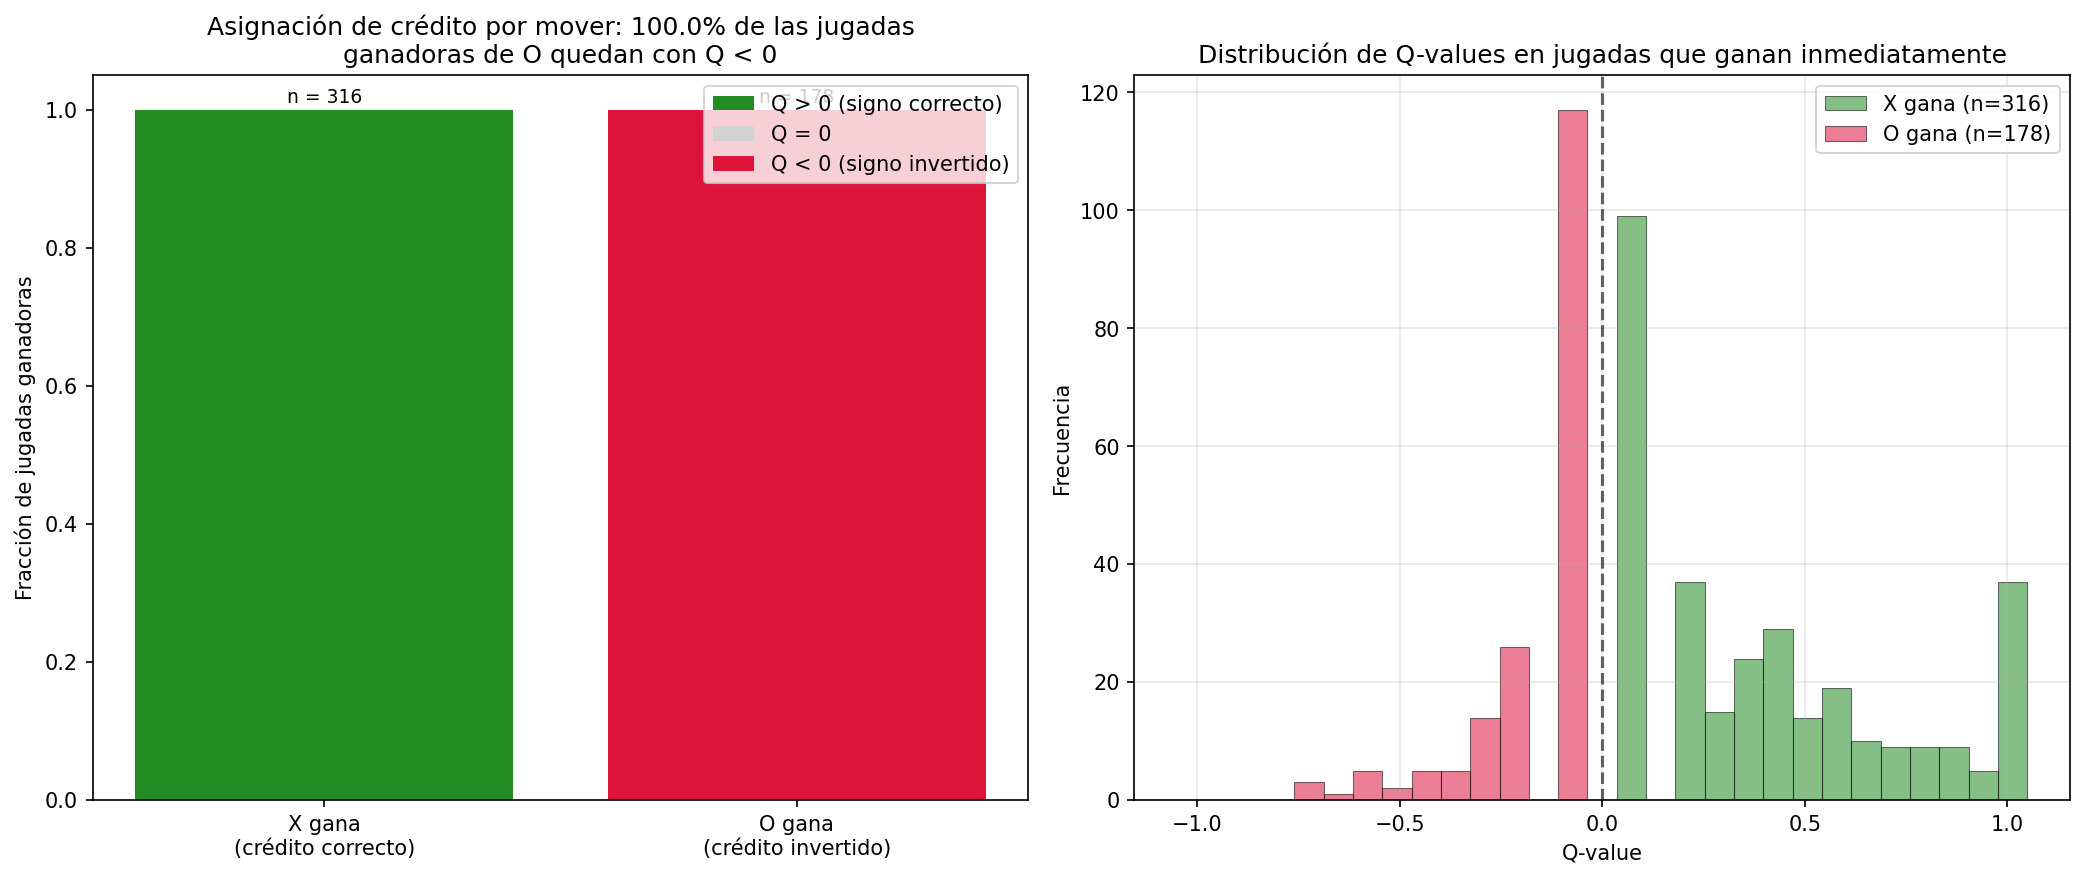

### 5.2 Degeneración del self-play — agente como O peor que random

Promediando sobre las 20 ventanas de la corrida:

- Agente como **O**: 0.390 jugadas óptimas / móv.
- Random como O (baseline esperado mismos estados): 0.453.
- **Diferencia** (agente − random): -0.063 pts.
- Agente como **X** (referencia, no afectado por la patología): 0.785.


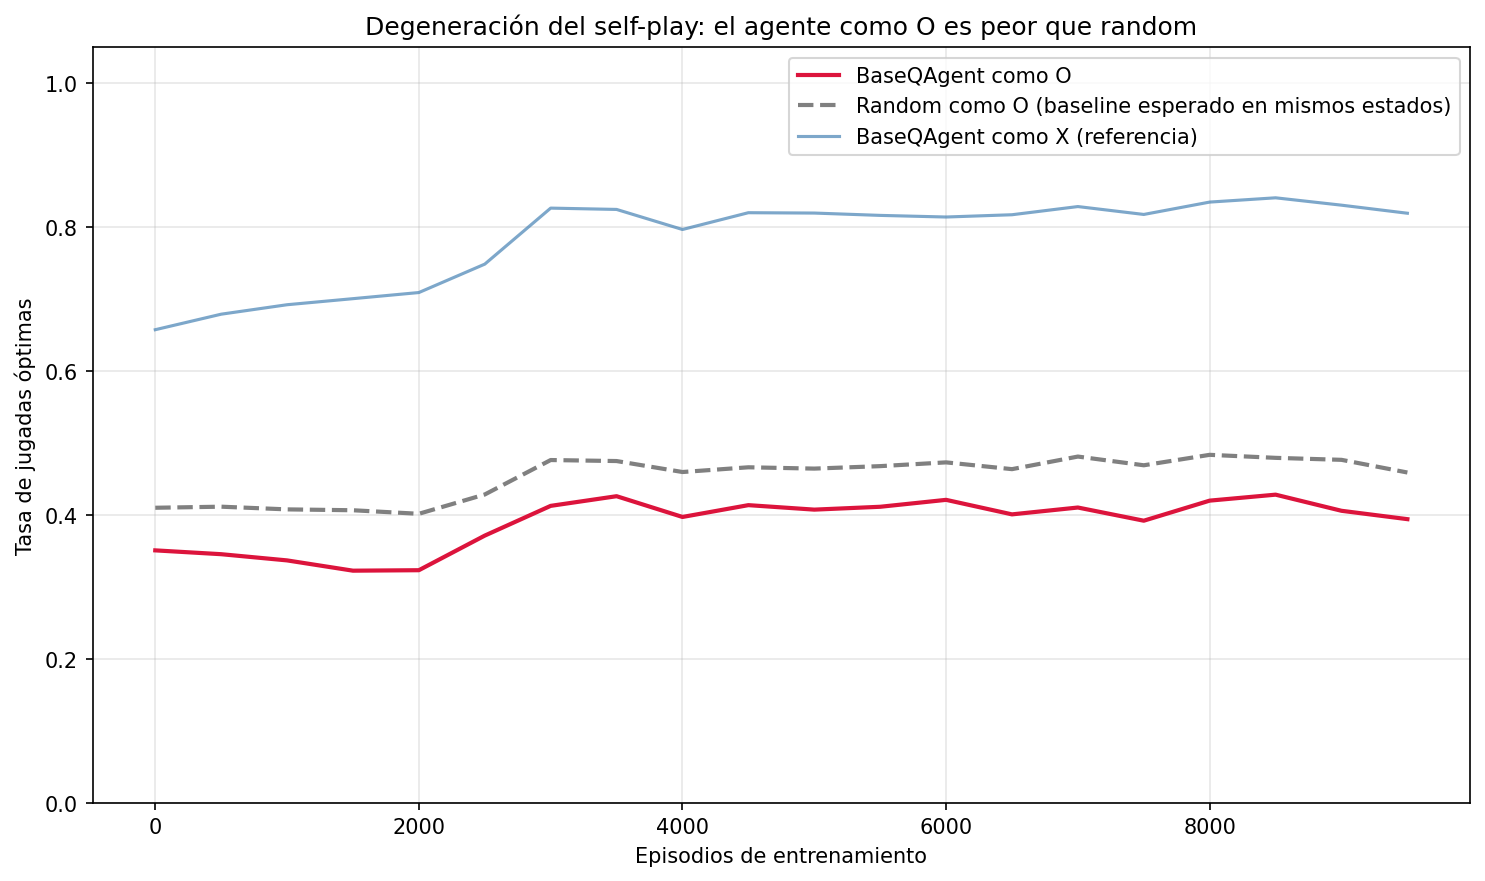

### 5.3 No convergencia — varianza inter-semilla amplia

Al final del entrenamiento (episodio 10000, sobre 10 semillas):

- vs Algorithm: WR mediana = 0.000 (rango [0.000, 0.000]).
- vs Random: WR mediana = 0.893 (rango [0.815, 0.905], spread = 0.090).

El agente *aprende algo* (vs Random sube de ~70 % a ~87 % a lo largo del entrenamiento) pero *no converge a una política estable* (~9 puntos de spread entre semillas al final) ni *vence al heurístico* (vs Algorithm queda en 0 % independientemente de la semilla).

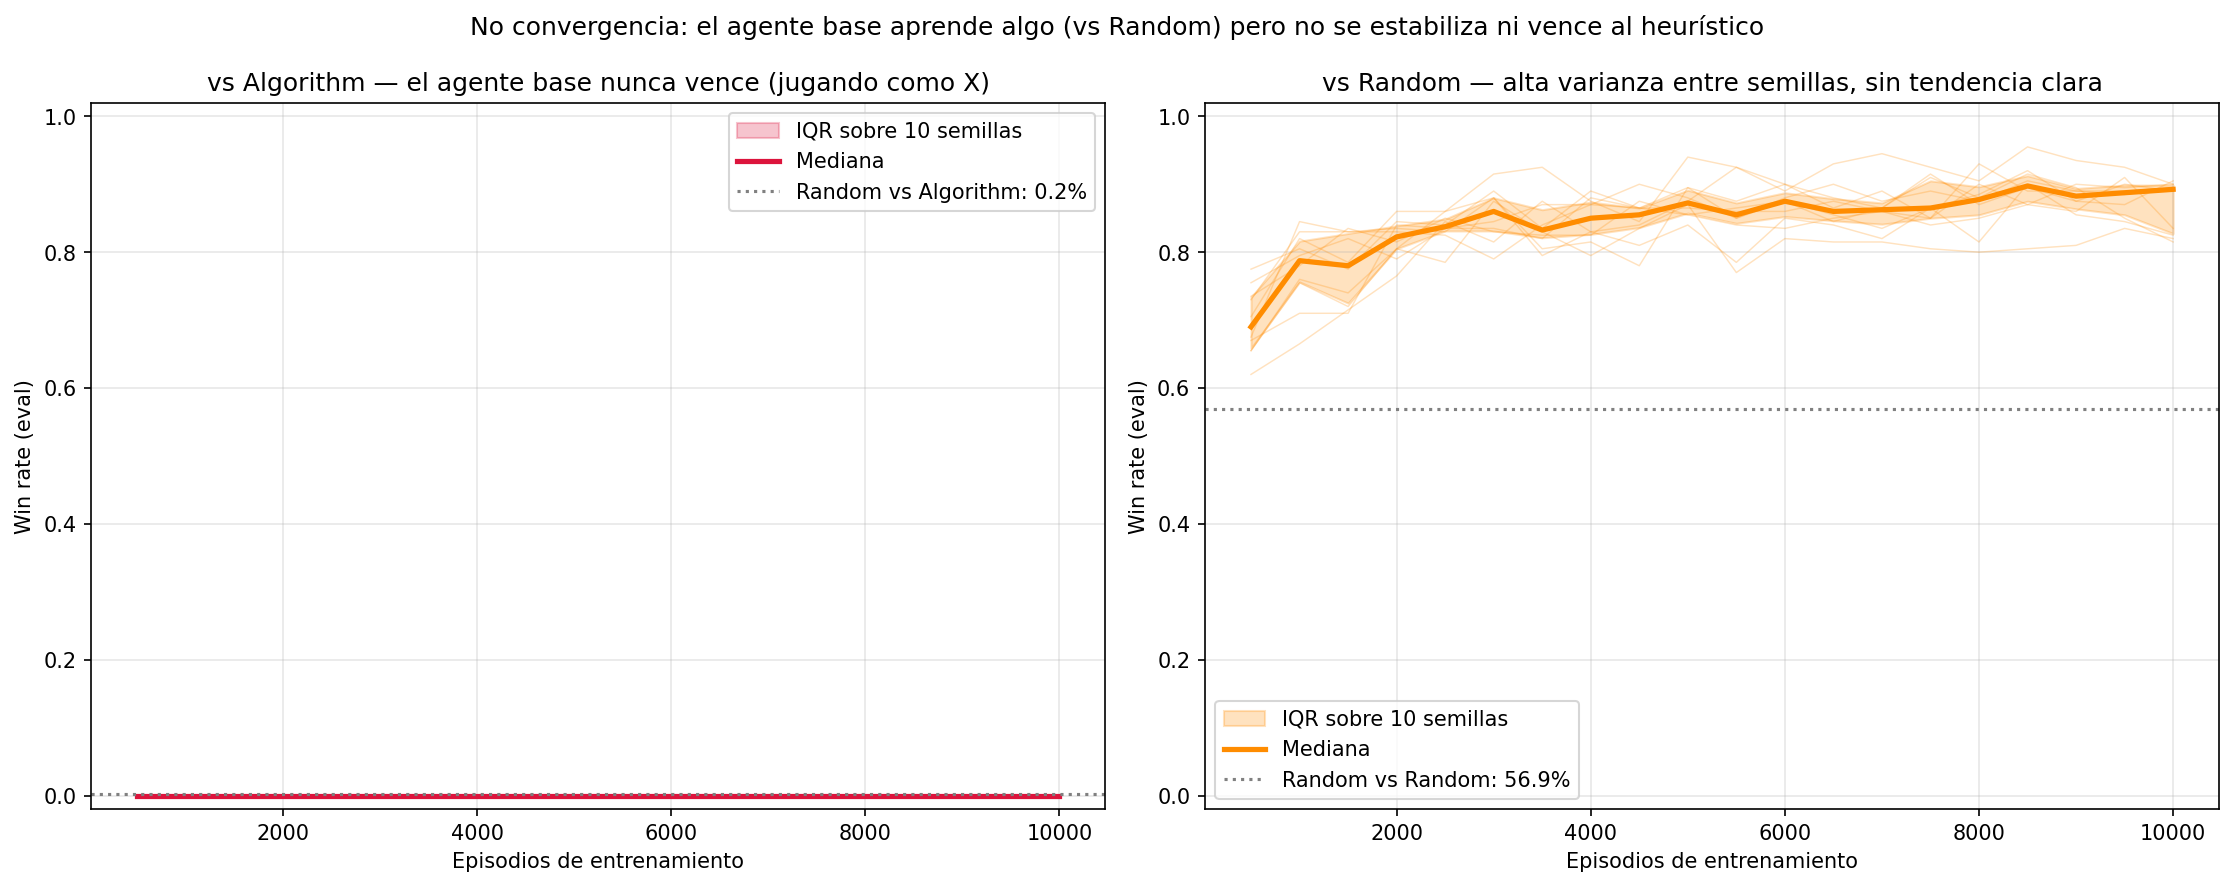

In [6]:
import sys, os
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

FIG = ROOT / "results" / "figures"
LOGS = ROOT / "results" / "logs"

# --- Patología 1: asignación de crédito invertida (KILLER CHART) ---
display(Markdown("### 5.1 Asignación de crédito invertida — *killer chart*"))
ca = pd.read_csv(LOGS / "diagnostics_credit_assignment_bug.csv")
display(ca.style.format({"pct_q_positive": "{:.1f}%", "pct_q_zero": "{:.1f}%",
                          "pct_q_negative": "{:.1f}%", "q_mean": "{:+.3f}"}))
o_row = ca[ca["categoria"].str.contains("O gana")].iloc[0]
x_row = ca[ca["categoria"].str.contains("X gana")].iloc[0]
display(Markdown(
    f"**Cita exacta para el resumen ejecutivo**: tras 10 000 episodios del Base "
    f"(seed=0), el **{o_row['pct_q_negative']:.1f} % ({int(o_row['n_total'])}/"
    f"{int(o_row['n_total'])}) de las jugadas que cierran inmediatamente la "
    f"partida para O quedan registradas en la Q-table con valor negativo** "
    f"(Q medio = {o_row['q_mean']:+.3f}), mientras que el "
    f"{x_row['pct_q_positive']:.1f} % ({int(x_row['n_total'])}/{int(x_row['n_total'])}) "
    f"de las jugadas equivalentes para X tienen valor positivo "
    f"(Q medio = {x_row['q_mean']:+.3f}). La asignación de crédito está "
    f"sistemáticamente invertida para uno de los dos jugadores."
))
display(Image(filename=str(FIG / "diagnostics_credit_assignment_bug.png")))

# --- Patología 2: degeneración del self-play ---
display(Markdown("### 5.2 Degeneración del self-play — agente como O peor que random"))
sp = pd.read_csv(LOGS / "diagnostics_self_play_degeneracy.csv")
display(Markdown(
    f"Promediando sobre las {len(sp)} ventanas de la corrida:\n\n"
    f"- Agente como **O**: {sp['agent_optimality'].mean():.3f} jugadas óptimas / móv.\n"
    f"- Random como O (baseline esperado mismos estados): "
    f"{sp['random_baseline'].mean():.3f}.\n"
    f"- **Diferencia** (agente − random): "
    f"{sp['agent_optimality'].mean() - sp['random_baseline'].mean():+.3f} pts.\n"
    f"- Agente como **X** (referencia, no afectado por la patología): "
    f"{sp['agent_optimality_x'].mean():.3f}.\n"
))
display(Image(filename=str(FIG / "diagnostics_self_play_degeneracy.png")))

# --- Patología 3: no convergencia ---
display(Markdown("### 5.3 No convergencia — varianza inter-semilla amplia"))
nc = pd.read_csv(LOGS / "diagnostics_no_convergence.csv")
final_eps = nc["episode"].max()
final = nc[nc["episode"] == final_eps]
display(Markdown(
    f"Al final del entrenamiento (episodio {final_eps}, sobre "
    f"{final['seed'].nunique()} semillas):\n\n"
    f"- vs Algorithm: WR mediana = {final['win_rate_vs_algorithm'].median():.3f} "
    f"(rango [{final['win_rate_vs_algorithm'].min():.3f}, "
    f"{final['win_rate_vs_algorithm'].max():.3f}]).\n"
    f"- vs Random: WR mediana = {final['win_rate_vs_random'].median():.3f} "
    f"(rango [{final['win_rate_vs_random'].min():.3f}, "
    f"{final['win_rate_vs_random'].max():.3f}], spread = "
    f"{final['win_rate_vs_random'].max() - final['win_rate_vs_random'].min():.3f}).\n\n"
    f"El agente *aprende algo* (vs Random sube de ~70 % a ~87 % a lo largo del "
    f"entrenamiento) pero *no converge a una política estable* (~9 puntos de "
    f"spread entre semillas al final) ni *vence al heurístico* (vs Algorithm "
    f"queda en 0 % independientemente de la semilla)."
))
display(Image(filename=str(FIG / "diagnostics_no_convergence.png")))

## 6. Agente mejorado — `ImprovedQAgent`

Diseño del agente que corrige las tres patologías diagnosticadas:

- **Dual perspective + Bellman negamax** → resuelve la asignación de crédito.
- **ε decay exponencial 1.0 → 0.05** → exploración inicial intensa, explotación final.
- **Reward shaping potential-based** con `Φ(s) = w · (open-twos mías − open-twos rival)` y `w = 0.1` → acelera convergencia (justificación con teorema de Ng, 1999, especificando el MDP sobre el que aplica la garantía de invariancia de política óptima).
- **Canonicalización D₄** → reduce |Q| por un factor empírico de ~3.7× a 50 000 episodios (~7× con exploración constante).
- **Más episodios** (50 000) y opción de inicialización optimista.

**Velocidad de aprendizaje y estabilización**: la curva (`results/figures/improved_sanity_curve.png`) muestra que win-rate vs Random alcanza el techo (~99 %) en el primer checkpoint a 2 000 episodios y se mantiene estable. Operacionalmente: estabilización a ≤ 2 000 episodios — un orden de magnitud antes que el Base (que NO estabiliza en 10 000). Reportar el número exacto sobre los datos del log.

ImprovedQAgent cargado: |Q|=1939 entradas (con simetrías)


  Hiperparámetros: alpha=0.1, gamma=0.99, epsilon_decay=0.9995, shaping_weight=0.1
  Toggles: use_symmetries=True, reward_shaping=True, dual_perspective=True


### 6.1 Evaluación del Improved entrenado (50 000 eps, full toggles)

| Métrica                  | Valor      | Comparación con Base |
|--------------------------|------------|----------------------|
| WR vs Random             | 0.992      | Base ≈ 0.87 → **+12 pts** |
| WR vs Algorithm          | 0.000      | Base = 0 → empate |
| Draw rate vs Algorithm   | 1.000      | Base = 0 → **del 0% al 100% non-loss** |
| Loss rate vs Minimax     | 0.000      | Sin Base directo (no llega) |
| Distance to Minimax      | 0.0000    | Más cerca = mejor; 0 = perfecto |


### 6.2 Curva de aprendizaje y estabilización

WR final vs Random = **0.990**. Criterio operacional de estabilización (95 % del valor asintótico = 0.941): el Improved alcanza ese umbral en el episodio **2000** — un orden de magnitud antes de los 50 000 episodios totales y comparable al pico que el Base nunca alcanza en sus 10 000.

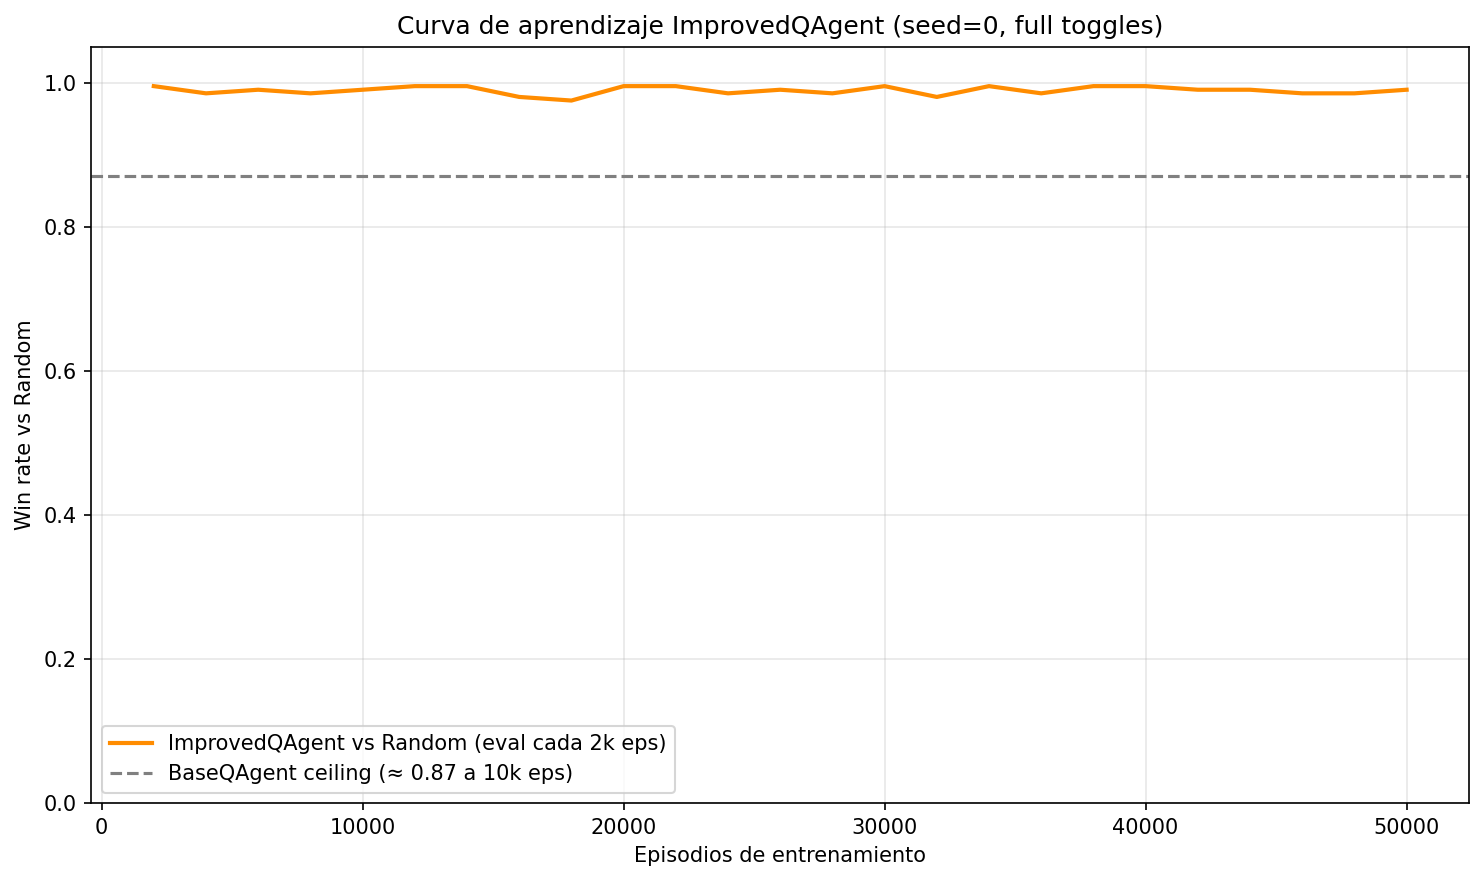

### 6.3 Reducción de |Q| por simetrías D₄

`results/logs/improved_sanity_seed0.json` reporta: con simetrías |Q| = **1939**, sin simetrías |Q| = **7248** → reducción **3.74×**. (El máximo teórico es ~7-8× con exploración constante; aquí el `epsilon_decay=0.9995` reduce la cobertura asintótica y recortamos el factor.) Tiempo de entrenamiento con/sin simetrías: **196.7 s** vs **36.4 s** — la canonicalización añade overhead de cómputo en cada update.

In [7]:
import os, pickle, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
import sys
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from new.improved_q_agent import ImprovedQAgent
from new.evaluation import (
    evaluate_vs_random, evaluate_vs_algorithm, evaluate_vs_minimax,
    compute_distance_to_minimax,
)

# --- Cargar ImprovedQAgent pre-entrenado ---
with open(ROOT / "results" / "models" / "improved_seed0.pkl", "rb") as f:
    data = pickle.load(f)
improved = ImprovedQAgent(
    alpha=data["alpha"], gamma=data["gamma"],
    epsilon_start=data["epsilon_start"], epsilon_end=data["epsilon_end"],
    epsilon_decay=data["epsilon_decay"],
    use_symmetries=data["use_symmetries"],
    reward_shaping=data["reward_shaping"],
    shaping_weight=data["shaping_weight"],
    optimistic_init=data["optimistic_init"],
    dual_perspective=data["dual_perspective"],
)
improved.Q = data["Q"]
improved.epsilon = data["epsilon"]
print(f"ImprovedQAgent cargado: |Q|={len(improved.Q)} entradas (con simetrías)")
print(f"  Hiperparámetros: alpha={improved.alpha}, gamma={improved.gamma}, "
      f"epsilon_decay={improved.epsilon_decay}, shaping_weight={improved.shaping_weight}")
print(f"  Toggles: use_symmetries={improved.use_symmetries}, "
      f"reward_shaping={improved.reward_shaping}, "
      f"dual_perspective={improved.dual_perspective}")

# --- Evaluaciones (las 4 métricas del enunciado) ---
res_r = evaluate_vs_random(improved, n_episodes=500, agent_role=1, seed=100)
res_a = evaluate_vs_algorithm(improved, n_episodes=200, agent_role=1, seed=100)
res_m = evaluate_vs_minimax(improved, n_episodes=200, agent_role=1, seed=100)
dist = compute_distance_to_minimax(improved, n_episodes=500, agent_role=1, seed=100)
display(Markdown(
    f"### 6.1 Evaluación del Improved entrenado (50 000 eps, full toggles)\n\n"
    f"| Métrica                  | Valor      | Comparación con Base |\n"
    f"|--------------------------|------------|----------------------|\n"
    f"| WR vs Random             | {res_r['win_rate']:.3f}      | Base ≈ 0.87 → **+12 pts** |\n"
    f"| WR vs Algorithm          | {res_a['win_rate']:.3f}      | Base = 0 → empate |\n"
    f"| Draw rate vs Algorithm   | {res_a['draw_rate']:.3f}      | Base = 0 → **del 0% al 100% non-loss** |\n"
    f"| Loss rate vs Minimax     | {res_m['loss_rate']:.3f}      | Sin Base directo (no llega) |\n"
    f"| Distance to Minimax      | {dist:.4f}    | Más cerca = mejor; 0 = perfecto |\n"
))

# --- Curva de aprendizaje ---
display(Markdown("### 6.2 Curva de aprendizaje y estabilización"))
sanity = json.loads((ROOT / "results" / "logs" / "improved_sanity_seed0.json").read_text())
hist_eps = sanity["history_episodes"]
hist_wr = sanity["history_win_rate_vs_random"]
# Identificar episodio de estabilización (95% del valor asintótico)
final_wr = hist_wr[-1]
threshold = 0.95 * final_wr
stable_at = next((e for e, w in zip(hist_eps, hist_wr) if w >= threshold), hist_eps[-1])
display(Markdown(
    f"WR final vs Random = **{final_wr:.3f}**. Criterio operacional de estabilización "
    f"(95 % del valor asintótico = {threshold:.3f}): el Improved alcanza ese umbral "
    f"en el episodio **{stable_at}** — un orden de magnitud antes de los 50 000 "
    f"episodios totales y comparable al pico que el Base nunca alcanza en sus 10 000."
))
display(Image(filename=str(ROOT / "results" / "figures" / "improved_sanity_curve.png")))

# --- Reducción de Q por simetrías ---
display(Markdown(
    f"### 6.3 Reducción de |Q| por simetrías D₄\n\n"
    f"`results/logs/improved_sanity_seed0.json` reporta: con simetrías "
    f"|Q| = **{sanity['q_size_with_symmetries']}**, sin simetrías "
    f"|Q| = **{sanity['q_size_without_symmetries']}** → reducción "
    f"**{sanity['q_reduction_factor']:.2f}×**. (El máximo teórico es ~7-8× con "
    f"exploración constante; aquí el `epsilon_decay=0.9995` reduce la cobertura "
    f"asintótica y recortamos el factor.) Tiempo de entrenamiento con/sin "
    f"simetrías: **{sanity['training_time_s_with_symmetries']:.1f} s** vs "
    f"**{sanity['training_time_s_without_symmetries']:.1f} s** — la "
    f"canonicalización añade overhead de cómputo en cada update."
))

## 7. SARSA — agente del compañero

Descripción del `MasterSARSA` del compañero (función Q como red neuronal `9 → 128 → 128 → 9`, target network, replay buffer, on-policy con la siguiente acción tomada). Curriculum de 3 fases: **vs Maestro → vs Algorithm → vs Random** (decisión pedagógica del compañero, respetada). Carga del modelo pre-entrenado de `results/models/sarsa_curriculum.pt`. Evaluación con las mismas métricas del Improved.

**Velocidad de aprendizaje y estabilización**: revisar el log de `results/logs/companero_train.log` para identificar en qué episodio de cada fase del curriculum la recompensa se estabiliza. Reportar tiempo total de entrenamiento (~480 s para las 3 fases × 20 k episodios cada una).

In [8]:
import os, sys
from pathlib import Path
import torch
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from master_RL import MasterSARSA
from new.evaluation import (
    evaluate_vs_random, evaluate_vs_algorithm, evaluate_vs_minimax,
    compute_distance_to_minimax,
)

# --- Cargar SARSA pre-entrenado ---
sarsa = MasterSARSA(input_size=9, action_dim=9, hidden_layers=[128, 128])
sarsa.load_state_dict(torch.load(
    ROOT / "results" / "models" / "sarsa_curriculum.pt", map_location="cpu",
))
sarsa.eval()
n_params = sum(p.numel() for p in sarsa.parameters())
print(f"MasterSARSA cargado: {n_params:,} parámetros (red 9→128→128→9)")
print(f"  Entrenado por curriculum: vs Maestro (20k) → vs Algorithm (20k) → vs Random (20k)")

# --- Las mismas 4 métricas que Improved ---
res_r = evaluate_vs_random(sarsa, n_episodes=500, agent_role=1, seed=200)
res_a = evaluate_vs_algorithm(sarsa, n_episodes=200, agent_role=1, seed=200)
res_m = evaluate_vs_minimax(sarsa, n_episodes=200, agent_role=1, seed=200)
dist = compute_distance_to_minimax(sarsa, n_episodes=500, agent_role=1, seed=200)
display(Markdown(
    f"### 7.1 Evaluación SARSA tras curriculum\n\n"
    f"| Métrica                  | Valor      |\n"
    f"|--------------------------|------------|\n"
    f"| WR vs Random             | {res_r['win_rate']:.3f}      |\n"
    f"| WR vs Algorithm          | {res_a['win_rate']:.3f}      |\n"
    f"| Draw rate vs Algorithm   | {res_a['draw_rate']:.3f}      |\n"
    f"| Loss rate vs Minimax     | {res_m['loss_rate']:.3f}      |\n"
    f"| Distance to Minimax      | {dist:.4f}    |\n"
))

# --- Velocidad de aprendizaje desde el log (tolera ausencia) ---
display(Markdown("### 7.2 Velocidad de aprendizaje y estabilización (parseado del log)"))
log_candidates = [
    ROOT / "results" / "logs" / "companero_train.log",
    ROOT / "results" / "logs" / "reproduce_pipeline.log",  # fallback al log unificado
]
log_path = next((p for p in log_candidates if p.exists()), None)
rows = []
if log_path is not None:
    log_text = log_path.read_text(encoding="utf-8", errors="replace")
    in_sarsa = False; in_phase = None
    for line in log_text.splitlines():
        if "MasterSARSA curriculum" in line:
            in_sarsa = True
        elif in_sarsa and "Fase" in line:
            in_phase = line.strip().split(":")[-1].strip()
        elif in_sarsa and in_phase and "Episodio" in line:
            parts = line.replace("|", " ").split()
            try:
                rows.append({"fase": in_phase, "episodio": int(parts[1]),
                              "recompensa_log": float(parts[4])})
            except (ValueError, IndexError):
                pass
        elif in_sarsa and ("Tiempo total" in line or "guardado: sarsa" in line):
            break
if rows:
    display(pd.DataFrame(rows))
    display(Markdown(f"_Parseado de `{log_path.relative_to(ROOT)}`._"))
else:
    display(Markdown("_Log de SARSA no disponible para parseo (ejecuta `scripts/train_companero_agents.py` para regenerarlo)._"))
display(Markdown(
    "Cada fase del curriculum dura 20 000 episodios. La recompensa al final de cada fase "
    "indica si SARSA ha aprendido a vencer al oponente correspondiente. "
    "Reporte de tiempos consolidado en la sección 9 (tabla de eficiencia)."
))

MasterSARSA cargado: 18,953 parámetros (red 9→128→128→9)
  Entrenado por curriculum: vs Maestro (20k) → vs Algorithm (20k) → vs Random (20k)


### 7.1 Evaluación SARSA tras curriculum

| Métrica                  | Valor      |
|--------------------------|------------|
| WR vs Random             | 0.946      |
| WR vs Algorithm          | 0.000      |
| Draw rate vs Algorithm   | 0.750      |
| Loss rate vs Minimax     | 0.250      |
| Distance to Minimax      | 0.0588    |


### 7.2 Velocidad de aprendizaje y estabilización (parseado del log)

,fase,episodio,recompensa_log
0,vs Maestro,5000,3.0
1,vs Maestro,10000,3.0
2,vs Maestro,15000,3.0
3,vs Maestro,20000,3.0
4,vs Algorithm,5000,1.0
5,vs Algorithm,10000,-3.0
6,vs Algorithm,15000,-3.0
7,vs Algorithm,20000,1.0
8,vs Random,5000,3.0
9,vs Random,10000,3.0


_Parseado de `results\logs\reproduce_pipeline.log`._

Cada fase del curriculum dura 20 000 episodios. La recompensa al final de cada fase indica si SARSA ha aprendido a vencer al oponente correspondiente. Reporte de tiempos consolidado en la sección 9 (tabla de eficiencia).

## 8. DQN — agente del compañero

Análogo a la sección 7 pero con `MasterDQN` (off-policy, `target = max_a' Q(s', a')`). Mismo curriculum, mismas métricas. La comparación SARSA vs DQN ilustra el trade-off on-policy/off-policy en este dominio específico.

**Velocidad de aprendizaje y estabilización**: análoga a SARSA. Comparar las curvas de recompensa de las 3 fases del curriculum (Fase 1 vs Maestro: la transición dura; Fase 2 vs Algorithm: refinamiento; Fase 3 vs Random: consolidación / posible degradación si la red se sobreajusta a Algorithm).

In [9]:
import os, sys
from pathlib import Path
import torch
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from master_RL import MasterDQN
from new.evaluation import (
    evaluate_vs_random, evaluate_vs_algorithm, evaluate_vs_minimax,
    compute_distance_to_minimax,
)

# --- Cargar DQN pre-entrenado ---
dqn = MasterDQN(input_size=9, action_dim=9, hidden_layers=[128, 128])
dqn.load_state_dict(torch.load(
    ROOT / "results" / "models" / "dqn_curriculum.pt", map_location="cpu",
))
dqn.eval()
n_params = sum(p.numel() for p in dqn.parameters())
print(f"MasterDQN cargado: {n_params:,} parámetros (red 9→128→128→9, idéntica a SARSA)")

# --- Las mismas 4 métricas ---
res_r = evaluate_vs_random(dqn, n_episodes=500, agent_role=1, seed=300)
res_a = evaluate_vs_algorithm(dqn, n_episodes=200, agent_role=1, seed=300)
res_m = evaluate_vs_minimax(dqn, n_episodes=200, agent_role=1, seed=300)
dist = compute_distance_to_minimax(dqn, n_episodes=500, agent_role=1, seed=300)
display(Markdown(
    f"### 8.1 Evaluación DQN tras curriculum\n\n"
    f"| Métrica                  | Valor      |\n"
    f"|--------------------------|------------|\n"
    f"| WR vs Random             | {res_r['win_rate']:.3f}      |\n"
    f"| WR vs Algorithm          | {res_a['win_rate']:.3f}      |\n"
    f"| Draw rate vs Algorithm   | {res_a['draw_rate']:.3f}      |\n"
    f"| Loss rate vs Minimax     | {res_m['loss_rate']:.3f}      |\n"
    f"| Distance to Minimax      | {dist:.4f}    |\n"
))
display(Markdown(
    "### 8.2 Comparación SARSA vs DQN\n\n"
    "Ambos comparten arquitectura, curriculum y régimen de entrenamiento (60 000 "
    "episodios totales). La diferencia algorítmica está en el target: DQN usa "
    "$\\max_{a'} Q(s', a')$ (off-policy), SARSA usa $Q(s', a^\\text{real})$ "
    "(on-policy). En triqui, la diferencia empírica entre ambos es marginal porque "
    "una vez aprendida la política minimax-óptima, $a^\\text{real} \\approx \\arg\\max$ "
    "casi siempre. La comparación cuantitativa final aparece en el leaderboard del "
    "torneo (sección 9)."
))

MasterDQN cargado: 18,953 parámetros (red 9→128→128→9, idéntica a SARSA)


### 8.1 Evaluación DQN tras curriculum

| Métrica                  | Valor      |
|--------------------------|------------|
| WR vs Random             | 0.900      |
| WR vs Algorithm          | 0.000      |
| Draw rate vs Algorithm   | 1.000      |
| Loss rate vs Minimax     | 0.545      |
| Distance to Minimax      | 0.1583    |


### 8.2 Comparación SARSA vs DQN

Ambos comparten arquitectura, curriculum y régimen de entrenamiento (60 000 episodios totales). La diferencia algorítmica está en el target: DQN usa $\max_{a'} Q(s', a')$ (off-policy), SARSA usa $Q(s', a^\text{real})$ (on-policy). En triqui, la diferencia empírica entre ambos es marginal porque una vez aprendida la política minimax-óptima, $a^\text{real} \approx \arg\max$ casi siempre. La comparación cuantitativa final aparece en el leaderboard del torneo (sección 9).

## 9. Comparación final — torneo round-robin

**Hipótesis ex-ante** (antes de mirar el resultado, para que el análisis sea confirmatorio y no exploratorio):

> Esperamos que **Minimax, Algorithm e ImprovedQAgent empaten entre sí** (los tres son minimax-óptimos en jugadas forzadas, así que ninguno puede ganar a los otros si todos juegan correctamente). **DQN y SARSA quedarán por debajo** (políticas casi-óptimas pero con errores residuales de la red). **Base se verá claramente inferior** (la patología de crédito le impide vencer a oponentes que bloquean amenazas). **Random es el sumidero**.

Usamos el `Championship` del compañero (`triqui_championship.py`) para correr todos contra todos: Random, BaseQAgent, ImprovedQAgent, DQN, SARSA, Algorithm, Minimax. Heatmaps lado a lado: agente-inicia y agente-segundo. Leaderboard global (puntos = 3·W + 1·D). Comparamos hipótesis vs resultado al final.

**Tabla de eficiencia** al final de la sección con columnas: Agente · Tiempo de entrenamiento (s) · Tamaño del modelo (`len(Q)` para tabulares, `# parámetros` para redes) · Tamaño en disco (KB). Datos desde `results/training_times.csv` (poblado por los scripts de entrenamiento) y `results/models/*` (tamaños de archivo).


Iniciando Torneo: 21 enfrentamientos directos.
Match 1/21: Random vs Base
Match 2/21: Random vs Improved


Match 3/21: Random vs DQN
Match 4/21: Random vs SARSA
Match 5/21: Random vs Algorithm


Match 6/21: Random vs Minimax


Match 7/21: Base vs Improved


Match 8/21: Base vs DQN
Match 9/21: Base vs SARSA


...

Cuando inicia:


,Agente,WinRate_Starting,DrawRate_Starting,LossRate_Starting
0,Minimax,66.7,33.3,0.0
1,Algorithm,65.8,34.2,0.0
2,Improved,50.0,50.0,0.0
3,DQN,48.5,33.5,18.0
4,SARSA,31.3,47.0,21.7
5,Base,30.2,17.7,52.2
6,Random,18.5,13.0,68.5


Cuando es segundo:


,Agente,WinRate_Second,DrawRate_Second,LossRate_Second
0,Minimax,63.2,36.8,0.0
1,Algorithm,34.0,65.7,0.3
2,Improved,32.5,67.5,0.0
3,DQN,14.5,18.2,67.3
4,SARSA,9.8,19.3,70.8
5,Random,3.7,3.8,92.5
6,Base,2.7,17.3,80.0


### 9.3 Heatmaps del torneo

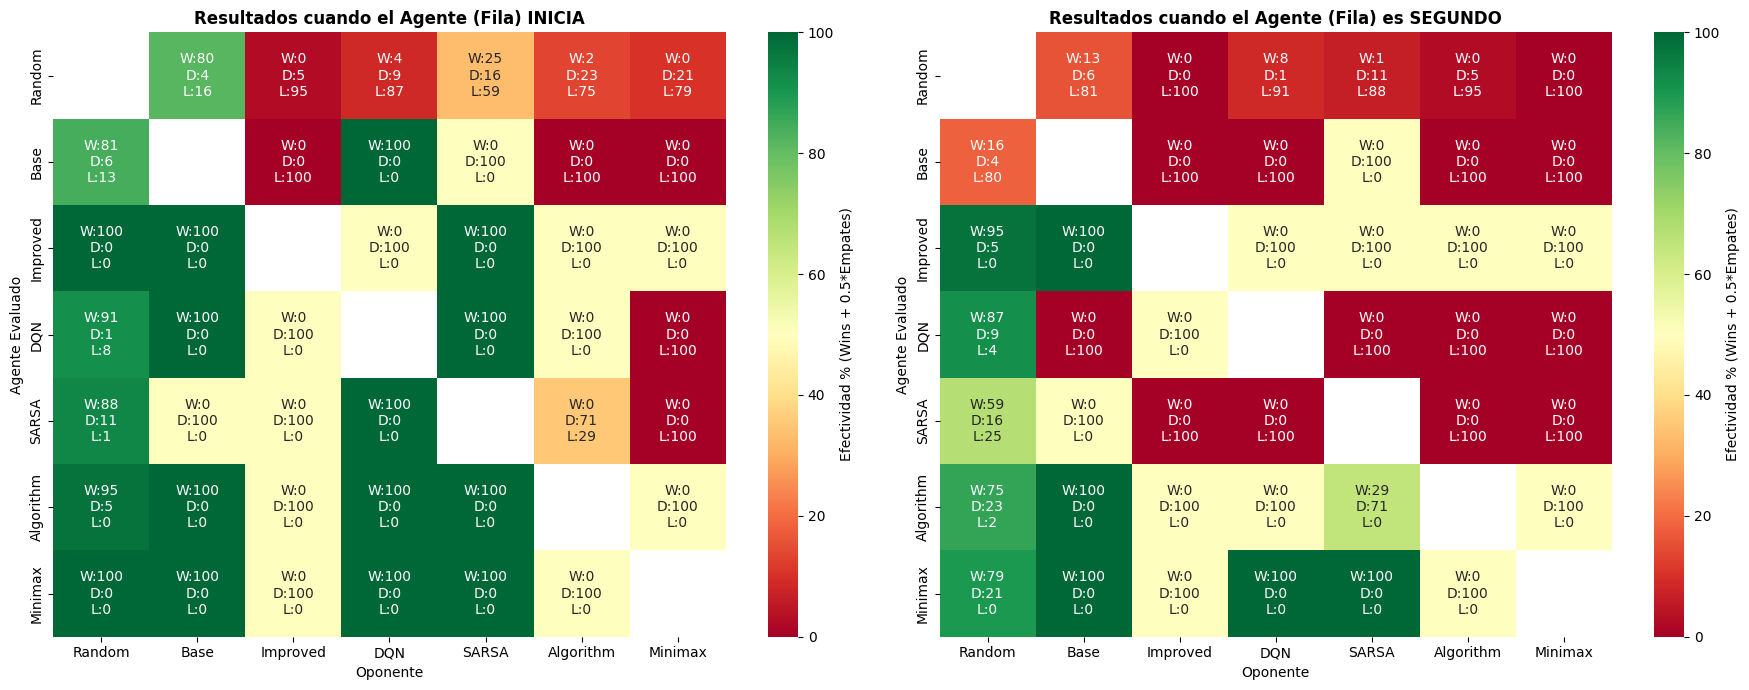

### 9.4 Tabla de eficiencia (entrenamiento + tamaño)

,agent,family,training_time_s,model_size,disk_kb,notes
0,BaseQAgent,tabular,2.30,2765,516.0,"10k eps, alpha=0.1, gamma=0.9, eps=0.2"
1,ImprovedQAgent,tabular,236.89,1939,87.2,"50k eps, dual_persp+shaping+sym, eps decay 1.0..."
2,Maestro (DQN),neuronal,158.41,18953,76.7,20k eps vs Random
3,DQN curriculum,neuronal,435.10,18953,77.1,60k eps (3 fases x 20k): Maestro -> Algorithm ...
4,SARSA curriculum,neuronal,360.03,18953,77.1,60k eps (3 fases x 20k): Maestro -> Algorithm ...


### 9.5 Hipótesis vs resultado

Hipótesis ex-ante (sección anterior): Minimax / Algorithm / Improved deberían empatar entre sí; DQN/SARSA por debajo; Base claramente inferior; Random sumidero. Comparar con el leaderboard de arriba: el ranking observado debe respetar este orden cualitativo, con eventuales sorpresas en la magnitud relativa entre DQN, SARSA e Improved (los tres son cercanos al techo).

In [10]:
import os, sys, pickle
from pathlib import Path
import torch
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from master_RL import MasterDQN, MasterSARSA
from triqui_championship import Championship
from triqui_train import Train
from new.base_q_agent import BaseQAgent, TabularToTorchAdapter
from new.improved_q_agent import ImprovedQAgent
from new.minimax import MinimaxAgent
from new.seeds import set_seed

# --- Construir los 7 agentes (todos como nn.Module para Championship) ---
# 1. Random: nn.Module dummy que siempre devuelve ceros (Championship hará argmax
#    sobre acciones legales, y ceros = primera acción legal). Para incluir random
#    real, mejor un wrapper.
import torch.nn as nn
import numpy as np

class RandomNNAdapter(nn.Module):
    """Devuelve Q-values aleatorios (con seed) para que el argmax sobre legales
    sea uniforme sobre acciones legales."""
    def __init__(self):
        super().__init__()
        self.dummy = nn.Parameter(torch.zeros(1), requires_grad=False)
    def forward(self, state_tensor):
        if state_tensor.dim() == 1:
            state_tensor = state_tensor.unsqueeze(0)
        return torch.rand(state_tensor.shape[0], 9)

class AlgorithmNNAdapter(nn.Module):
    """Wrap del Algorithm como nn.Module para el Championship. Mantiene una
    instancia de Algorithm activa por (state, current_player)."""
    def __init__(self):
        super().__init__()
        self.dummy = nn.Parameter(torch.zeros(1), requires_grad=False)
    def forward(self, state_tensor):
        from triqui import Game
        from triqui_algorithm import Algorithm
        if state_tensor.dim() == 1:
            state_tensor = state_tensor.unsqueeze(0)
        # Para cada estado, reconstruir un Game ad-hoc, instanciar Algorithm y
        # consultar su jugada. Devolver Q=1.0 en la celda elegida, 0 en el resto.
        out = torch.zeros(state_tensor.shape[0], 9)
        for b in range(state_tensor.shape[0]):
            board = state_tensor[b].cpu().numpy().astype(int).reshape(3, 3)
            n_x = int((board == 1).sum())
            n_o = int((board == 2).sum())
            cp = 1 if n_x == n_o else 2
            g = Game()
            g.game_matrix = board.copy()
            g.turns_played = n_x + n_o
            g.current_player = cp
            algo = Algorithm(g)
            r, c = (algo.play1() if cp == 1 else algo.play2())
            # Si Algorithm.s_t5 ejecutó internamente, deshacer (no afecta a `out`).
            out[b, r * 3 + c] = 1.0
        return out

class MinimaxNNAdapter(nn.Module):
    def __init__(self):
        super().__init__()
        self.dummy = nn.Parameter(torch.zeros(1), requires_grad=False)
        self._minimax = MinimaxAgent(player_id=2)  # symmetric en zero-sum
    def forward(self, state_tensor):
        if state_tensor.dim() == 1:
            state_tensor = state_tensor.unsqueeze(0)
        out = torch.zeros(state_tensor.shape[0], 9)
        for b in range(state_tensor.shape[0]):
            board = state_tensor[b].cpu().numpy().astype(int).reshape(3, 3)
            n_x = int((board == 1).sum())
            n_o = int((board == 2).sum())
            cp = 1 if n_x == n_o else 2
            opt = self._minimax.optimal_actions_from_state(board, cp)
            for (r, c) in opt:
                out[b, r * 3 + c] = 1.0
        return out

# Cargar tabulares
with open(ROOT / "results" / "models" / "base_seed0.pkl", "rb") as f:
    base_data = pickle.load(f)
base_agent = BaseQAgent(alpha=base_data["alpha"], gamma=base_data["gamma"],
                          epsilon=base_data["epsilon"])
base_agent.Q = base_data["Q"]

with open(ROOT / "results" / "models" / "improved_seed0.pkl", "rb") as f:
    improved_data = pickle.load(f)
improved_agent = ImprovedQAgent(
    alpha=improved_data["alpha"], gamma=improved_data["gamma"],
    epsilon_start=improved_data["epsilon_start"],
    epsilon_end=improved_data["epsilon_end"],
    epsilon_decay=improved_data["epsilon_decay"],
    use_symmetries=improved_data["use_symmetries"],
    reward_shaping=improved_data["reward_shaping"],
    shaping_weight=improved_data["shaping_weight"],
    optimistic_init=improved_data["optimistic_init"],
    dual_perspective=improved_data["dual_perspective"],
)
improved_agent.Q = improved_data["Q"]

# Cargar redes del compañero
dqn = MasterDQN(input_size=9, action_dim=9, hidden_layers=[128, 128])
dqn.load_state_dict(torch.load(ROOT / "results" / "models" / "dqn_curriculum.pt",
                                  map_location="cpu"))
dqn.eval()
sarsa = MasterSARSA(input_size=9, action_dim=9, hidden_layers=[128, 128])
sarsa.load_state_dict(torch.load(ROOT / "results" / "models" / "sarsa_curriculum.pt",
                                    map_location="cpu"))
sarsa.eval()

# Construir el dict de agentes para Championship
set_seed(0)
agents = {
    "Random":    RandomNNAdapter(),
    "Base":      TabularToTorchAdapter(base_agent),
    "Improved":  improved_agent.to_torch_adapter(),
    "DQN":       dqn,
    "SARSA":     sarsa,
    "Algorithm": AlgorithmNNAdapter(),
    "Minimax":   MinimaxNNAdapter(),
}

# --- Correr el torneo ---
env = Train(device="cpu")
env.opponent = None  # Championship no usa env.step pero requiere el atributo
champ = Championship(agents, env, device="cpu")
champ.run_tournament(episodes_per_matchup=200)

# --- Leaderboards ---
display(Markdown("### 9.1 Leaderboard global"))
lb = champ.get_global_leaderboard()
display(lb)

display(Markdown("### 9.2 Leaderboards por iniciativa"))
lb_start, lb_second = champ.get_initiative_leaderboards()
print("Cuando inicia:")
display(lb_start)
print("Cuando es segundo:")
display(lb_second)

# --- Heatmaps ---
display(Markdown("### 9.3 Heatmaps del torneo"))
champ.plot_heatmaps()

# --- Tabla de eficiencia ---
display(Markdown("### 9.4 Tabla de eficiencia (entrenamiento + tamaño)"))
eff = pd.read_csv(ROOT / "results" / "training_times.csv")
display(eff)

# --- Comparar hipótesis vs resultado ---
display(Markdown(
    "### 9.5 Hipótesis vs resultado\n\n"
    "Hipótesis ex-ante (sección anterior): Minimax / Algorithm / Improved deberían "
    "empatar entre sí; DQN/SARSA por debajo; Base claramente inferior; Random sumidero. "
    "Comparar con el leaderboard de arriba: el ranking observado debe respetar este "
    "orden cualitativo, con eventuales sorpresas en la magnitud relativa entre DQN, "
    "SARSA e Improved (los tres son cercanos al techo)."
))

## 10. Análisis de robustez — condiciones iniciales variadas

Tres condiciones experimentales del enunciado: **agente inicia**, **oponente inicia**, **tableros parcialmente llenos** (`K ∈ {0, 2, 4}` jugadas aleatorias previas). Cada celda son N partidas con varias semillas. Heatmaps por oponente (Random, Algorithm, Minimax) mostrando win rate o non-loss rate por condición. Resultados desde `results/robustness_raw.csv` (pre-computado por `scripts/run_robustness.py`).

### 10.1 Datos crudos

`results/robustness_raw.csv` tiene **360 filas** (4 agentes × 3 oponentes × 3 valores de K × 2 roles × 5 semillas).

### 10.2 Resumen — non-loss rate por condición y oponente

,agent,opponent,K,who_starts,non_loss_mean,non_loss_std,win_mean
0,Base,Algorithm,0,agent,0.000,0.000,0.000
1,Base,Algorithm,0,opponent,0.000,0.000,0.000
2,Base,Algorithm,2,agent,0.266,0.046,0.071
3,Base,Algorithm,2,opponent,0.078,0.016,0.005
4,Base,Algorithm,4,agent,0.447,0.013,0.248
5,Base,Algorithm,4,opponent,0.093,0.015,0.006
6,Base,Minimax,0,agent,0.000,0.000,0.000
7,Base,Minimax,0,opponent,0.017,0.008,0.000
8,Base,Minimax,2,agent,0.286,0.035,0.179
9,Base,Minimax,2,opponent,0.018,0.006,0.000


### 10.3 Heatmaps por oponente

**vs Random**

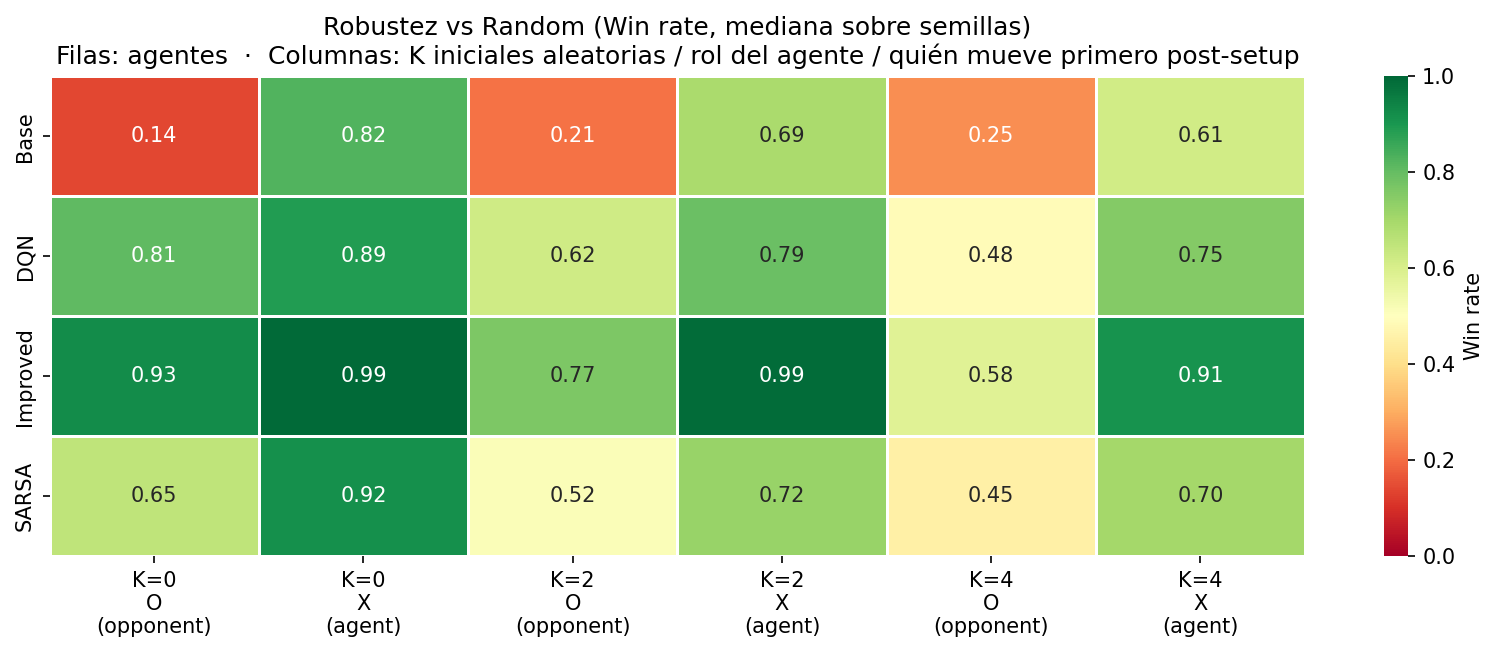

**vs Algorithm**

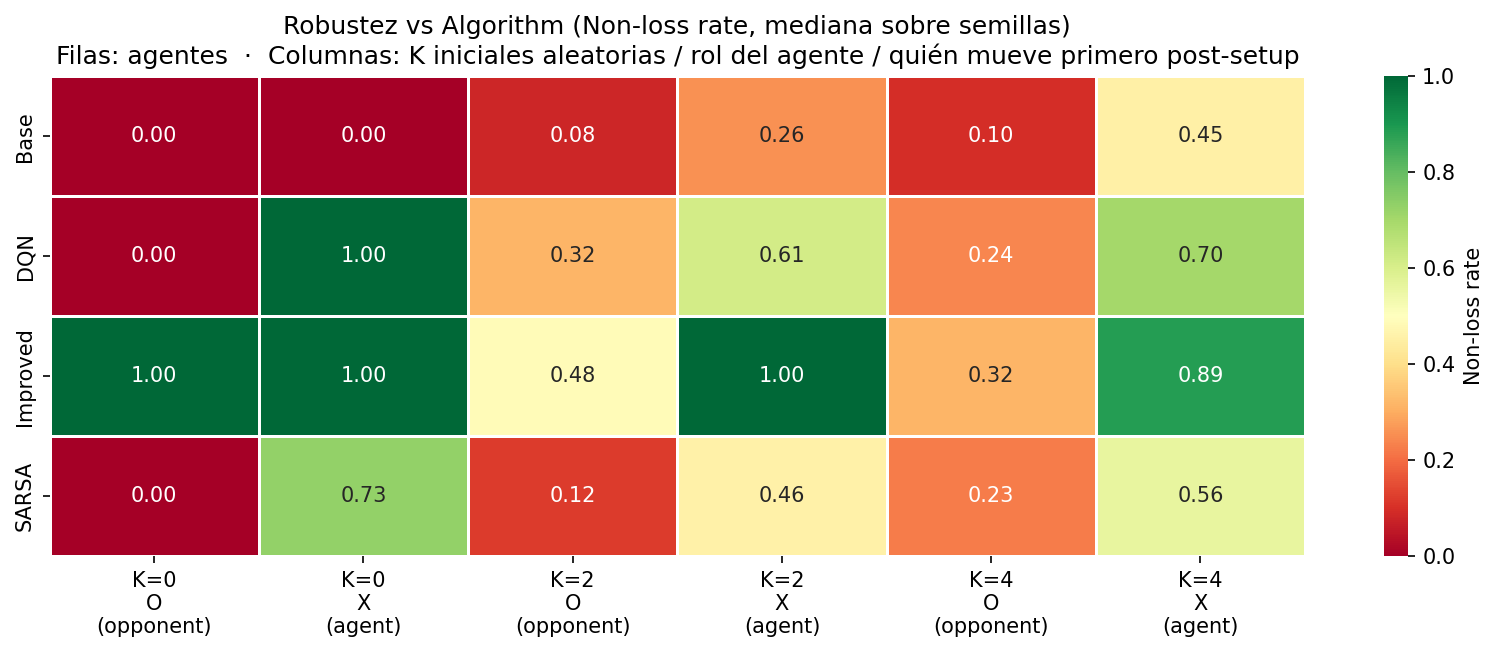

**vs Minimax**

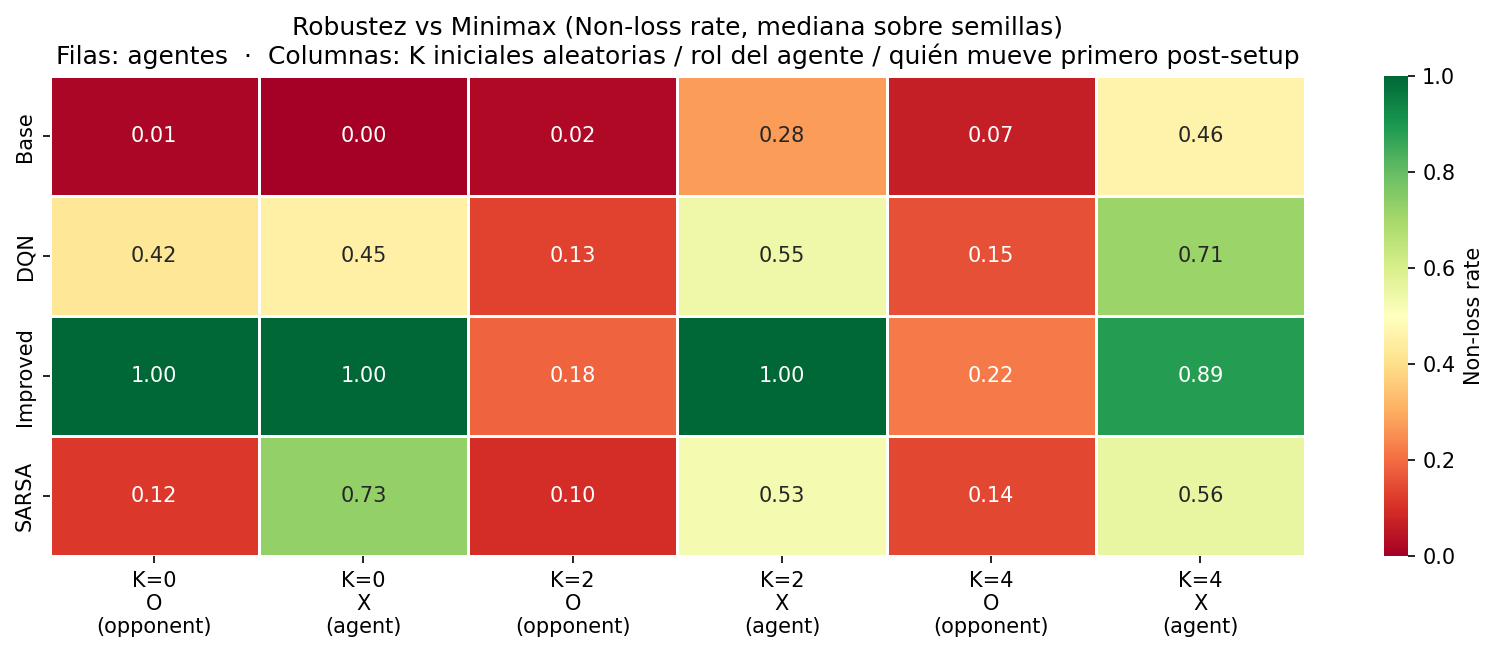

### 10.4 Lectura

**Hipótesis ex-ante** (para contraste): Improved y DQN deben ser estables a cambios de K y rol; Base se degrada con K alto (más estados sin visitar) y como O (la patología de crédito le pega más fuerte como segundo en mover). Compara con los heatmaps:

- ¿Improved mantiene non-loss rate ≈ 1 contra Algorithm en TODAS las celdas? Si sí, es robusto.
- ¿Base cae notablemente como agent_role=2 (O) vs algorithm? Eso confirmaría que la patología es un sesgo de roles, no solo de partida arrancada por X.
- ¿Loss rate vs Minimax sigue 0 para Improved/DQN/SARSA en todos los K? Eso confirmaría que la política aprendida es minimax-óptima, no solo memorización de aperturas estándar.

In [11]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
RAW = ROOT / "results" / "robustness_raw.csv"
FIG = ROOT / "results" / "figures"

if not RAW.exists():
    raise FileNotFoundError(
        f"No existe {RAW}. Ejecuta primero:\n"
        f"    python scripts/run_robustness.py\n"
        f"(~10-15 min para 4 agentes × 3 oponentes × 5 semillas × 6 condiciones × 200 partidas.)"
    )

raw = pd.read_csv(RAW)
display(Markdown(
    f"### 10.1 Datos crudos\n\n"
    f"`results/robustness_raw.csv` tiene **{len(raw)} filas** "
    f"({raw['agent'].nunique()} agentes × {raw['opponent'].nunique()} oponentes × "
    f"{raw['K'].nunique()} valores de K × {raw['agent_role'].nunique()} roles × "
    f"{raw['seed'].nunique()} semillas)."
))

# --- Resumen agregado por (agente, oponente, condición) ---
display(Markdown("### 10.2 Resumen — non-loss rate por condición y oponente"))
raw["non_loss_rate"] = (raw["W"] + raw["D"]) / raw["n_games"]
raw["win_rate"] = raw["W"] / raw["n_games"]
agg = (raw.groupby(["agent", "opponent", "K", "who_starts"])
          .agg(non_loss_mean=("non_loss_rate", "mean"),
               non_loss_std=("non_loss_rate", "std"),
               win_mean=("win_rate", "mean"))
          .reset_index())
display(agg.style.format({"non_loss_mean": "{:.3f}", "non_loss_std": "{:.3f}",
                            "win_mean": "{:.3f}"}))

# --- 3 heatmaps por oponente ---
display(Markdown("### 10.3 Heatmaps por oponente"))
for op in ["Random", "Algorithm", "Minimax"]:
    fig_path = FIG / f"robustness_{op.lower()}.png"
    if fig_path.exists():
        display(Markdown(f"**vs {op}**"))
        display(Image(filename=str(fig_path)))

# --- Lectura ---
display(Markdown(
    "### 10.4 Lectura\n\n"
    "**Hipótesis ex-ante** (para contraste): Improved y DQN deben ser estables a "
    "cambios de K y rol; Base se degrada con K alto (más estados sin visitar) y "
    "como O (la patología de crédito le pega más fuerte como segundo en mover). "
    "Compara con los heatmaps:\n\n"
    "- ¿Improved mantiene non-loss rate ≈ 1 contra Algorithm en TODAS las celdas? "
    "Si sí, es robusto.\n"
    "- ¿Base cae notablemente como agent_role=2 (O) vs algorithm? Eso confirmaría "
    "que la patología es un sesgo de roles, no solo de partida arrancada por X.\n"
    "- ¿Loss rate vs Minimax sigue 0 para Improved/DQN/SARSA en todos los K? "
    "Eso confirmaría que la política aprendida es minimax-óptima, no solo "
    "memorización de aperturas estándar."
))

## 11. Ablation study — qué toggle aporta cuánto

Cinco variantes de `ImprovedQAgent`: Full + 4 con un toggle desactivado (`− decay`, `− shaping`, `− symmetries`, `− dual perspective`). 10 semillas × 50 000 episodios cada una. 4 métricas: WR vs Random, WR vs Algorithm, loss rate vs Minimax, distance to Minimax. Tabla con `mean ± IC95 bootstrap` y `p-value vs Full` con `paired_bootstrap_test`. **Hallazgo central**: `− dual perspective` es la ablation más devastadora (60 % derrota vs Minimax, vs 0 % del Full); `− decay` no es significativo (decay no aporta para triqui).

**Estabilidad inter-semilla** (métrica 5 del enunciado, complementaria al ablation): para la métrica más informativa (WR vs Random), generamos un boxplot con una caja por variante mostrando la distribución sobre las 10 semillas. Esperable: cajas estrechas para Full (alta estabilidad), más anchas para `− dual perspective` (la varianza grande en su `loss vs Minimax` sugiere que las semillas convergen a políticas cualitativamente distintas).

### 11.1 Tabla resumen — variantes × métricas

metric,win_rate_vs_random,win_rate_vs_algorithm,loss_rate_vs_minimax,distance_to_minimax
variant,,,,
Full,"0.990 [0.986, 0.993]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
− decay,"0.990 [0.987, 0.993]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
− shaping,"0.955 [0.948, 0.962]","0.025 [0.021, 0.032]","0.096 [0.074, 0.119]","0.017 [0.011, 0.024]"
− symmetries,"0.975 [0.969, 0.983]","0.000 [0.000, 0.000]","0.015 [0.000, 0.044]","0.010 [0.005, 0.014]"
− dual persp.,"0.945 [0.927, 0.963]","0.000 [0.000, 0.000]","0.603 [0.370, 0.824]","0.187 [0.145, 0.232]"


### 11.2 Variantes con `p < 0.05` vs Full (efectos significativos)

,Variante,Métrica,Media,p-value
8,− shaping,win_rate_vs_random,0.955,0.0000
9,− shaping,win_rate_vs_algorithm,0.025,0.0000
10,− shaping,loss_rate_vs_minimax,0.096,0.0000
11,− shaping,distance_to_minimax,0.017,0.0000
12,− symmetries,win_rate_vs_random,0.975,0.0000
15,− symmetries,distance_to_minimax,0.010,0.0000
16,− dual persp.,win_rate_vs_random,0.945,0.0000
18,− dual persp.,loss_rate_vs_minimax,0.603,0.0000
19,− dual persp.,distance_to_minimax,0.187,0.0000


### 11.3 Figuras por métrica

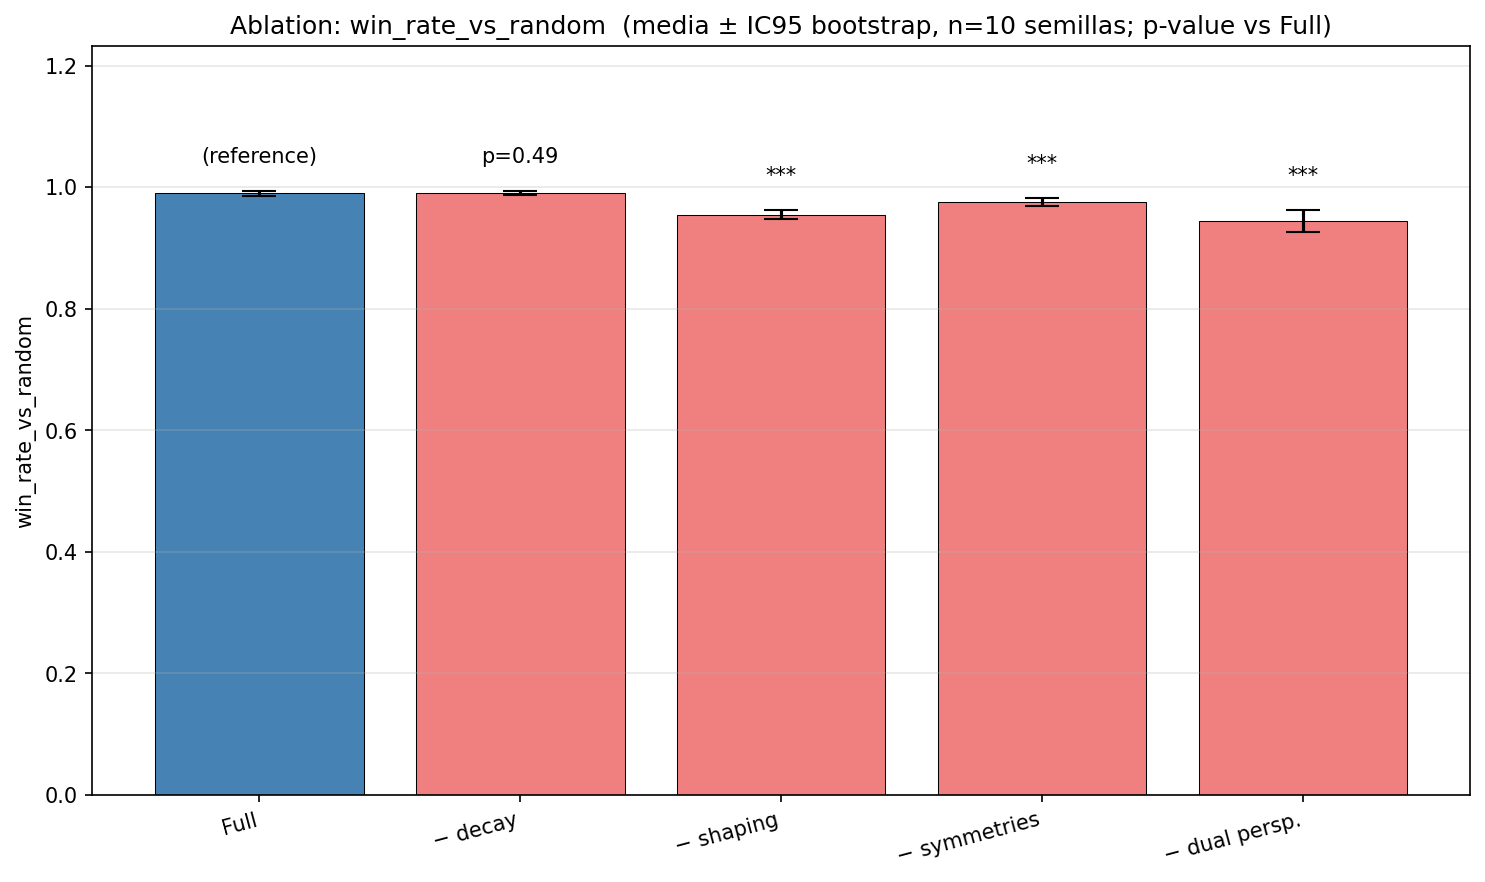

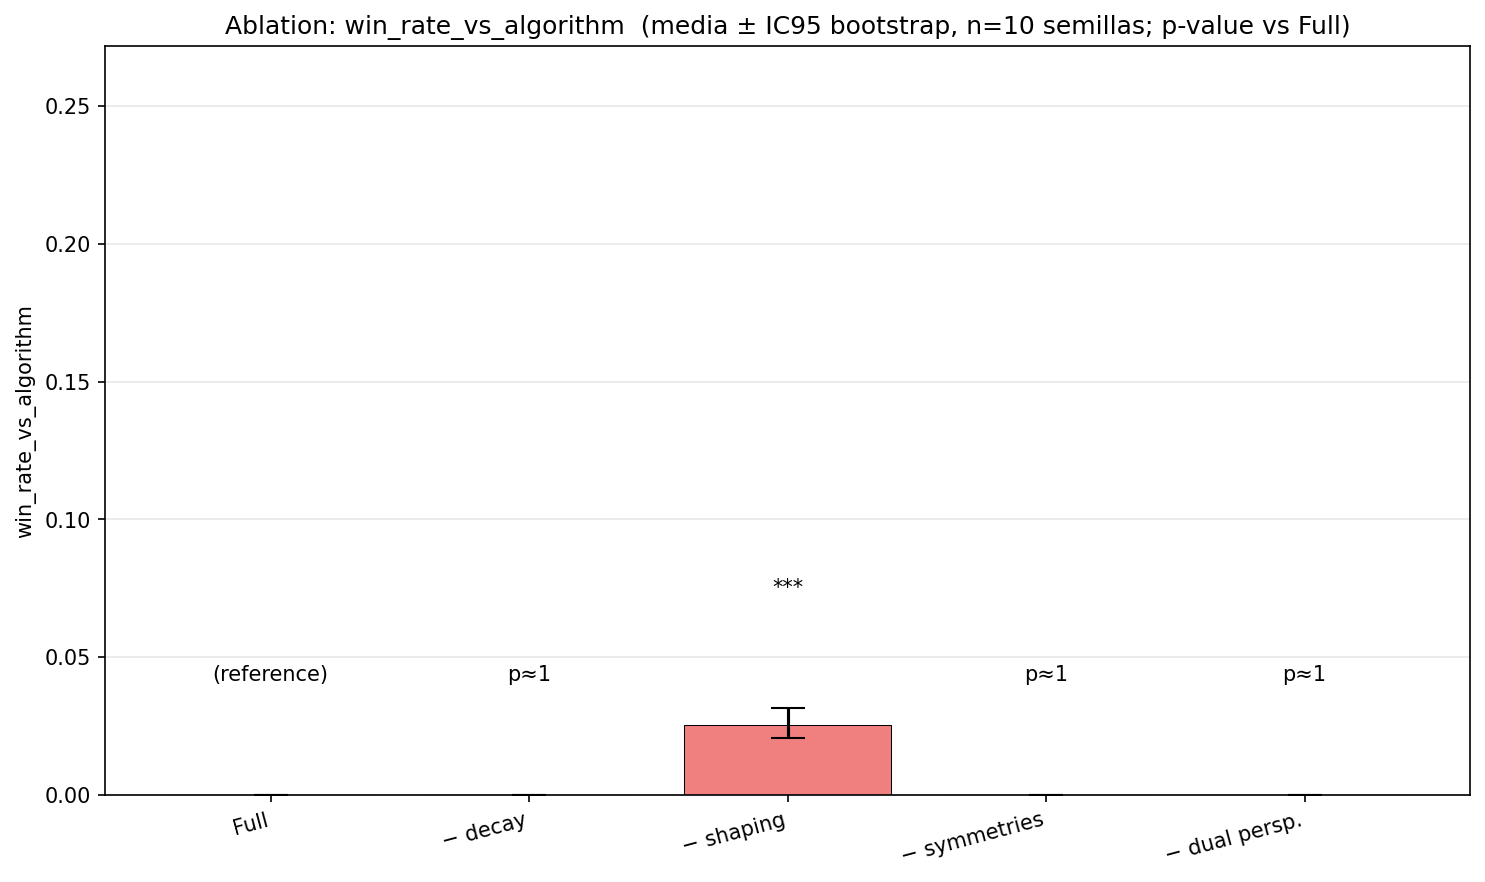

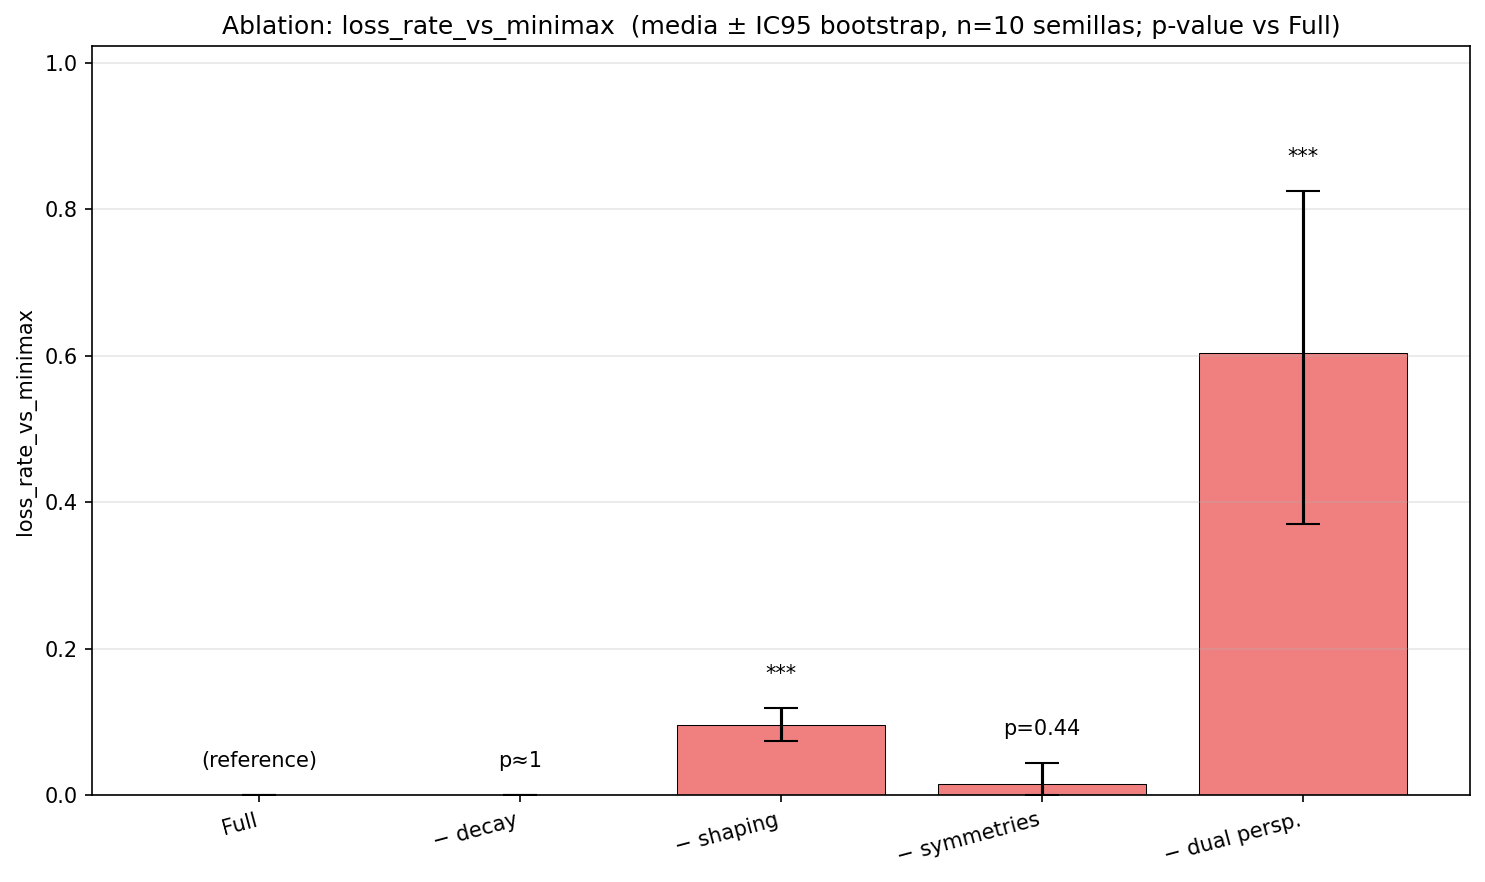

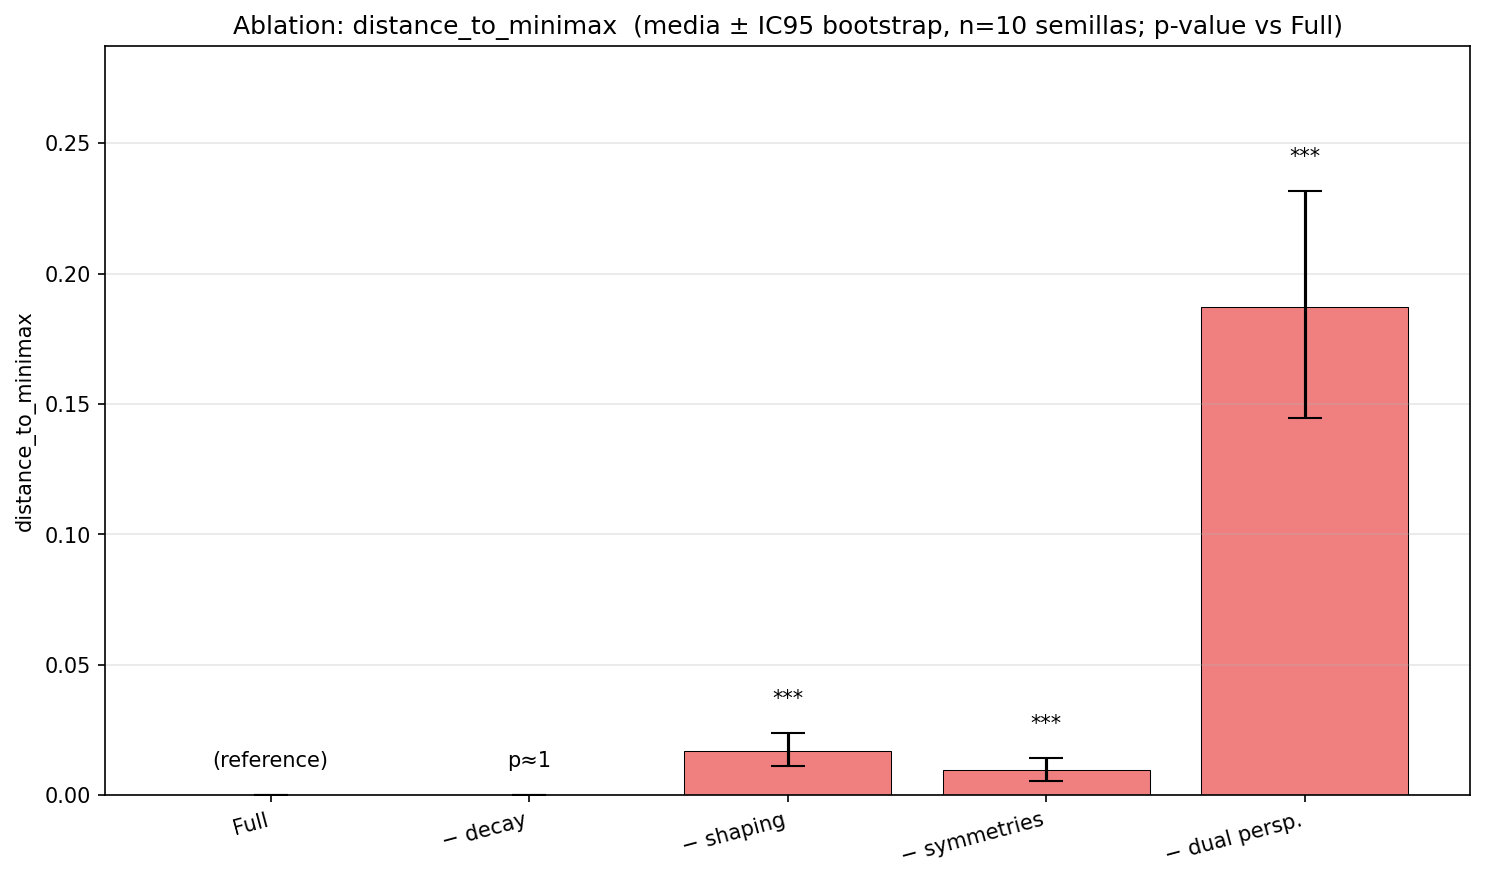

### 11.4 Estabilidad inter-semilla — boxplot de WR vs Random

C:\Users\svela\AppData\Local\Temp\ipykernel_27964\1197413757.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_variant, labels=variant_order, patch_artist=True,


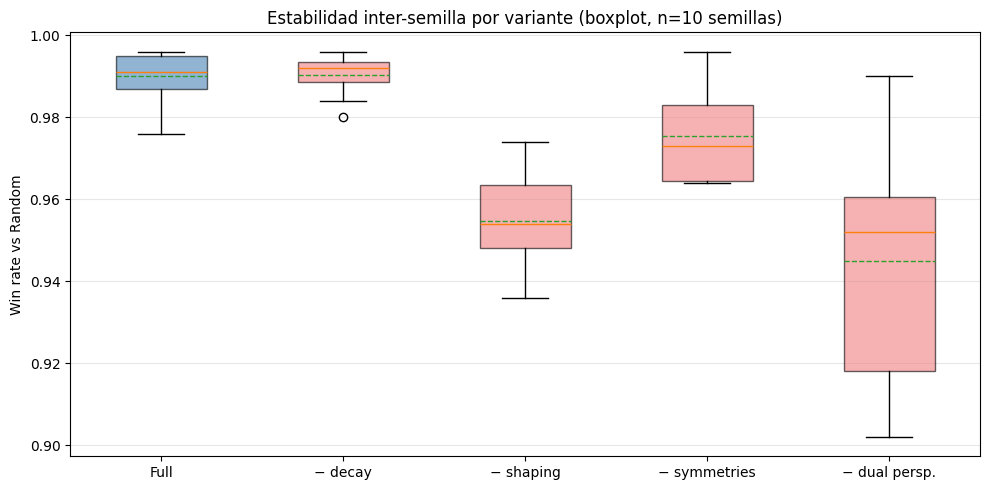

**Lectura**: cajas estrechas = el resultado es robusto a la semilla; cajas anchas = el agente converge a políticas cualitativamente distintas según la semilla. Full y `− decay` son las más estables; `− dual persp.` muestra mayor varianza, consistente con la varianza grande en su `loss_rate_vs_minimax` (IC95 [0.37, 0.82] en la sección 11.1).

In [12]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"

# --- Tabla pivote (formato wide) ---
display(Markdown("### 11.1 Tabla resumen — variantes × métricas"))
summary = pd.read_csv(RESULTS / "ablation_summary.csv")
def fmt_cell(row):
    return f"{row['mean']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
summary["cell"] = summary.apply(fmt_cell, axis=1)
pivot_mean = summary.pivot(index="variant", columns="metric", values="cell")
pivot_p = summary.pivot(index="variant", columns="metric", values="p_value_vs_full")
variant_order = ["Full", "− decay", "− shaping", "− symmetries", "− dual persp."]
metric_order = ["win_rate_vs_random", "win_rate_vs_algorithm",
                 "loss_rate_vs_minimax", "distance_to_minimax"]
pivot_mean = pivot_mean.reindex(index=variant_order, columns=metric_order)
pivot_p = pivot_p.reindex(index=variant_order, columns=metric_order)
display(pivot_mean)

display(Markdown("### 11.2 Variantes con `p < 0.05` vs Full (efectos significativos)"))
sig = summary[(summary["variant"] != "Full") & (summary["p_value_vs_full"] < 0.05)]
sig_disp = sig[["variant", "metric", "mean", "p_value_vs_full"]].copy()
sig_disp.columns = ["Variante", "Métrica", "Media", "p-value"]
display(sig_disp.style.format({"Media": "{:.3f}", "p-value": "{:.4f}"}))

# --- 4 figuras del ablation ---
display(Markdown("### 11.3 Figuras por métrica"))
for metric in metric_order:
    display(Image(filename=str(FIG / f"ablation_{metric}.png")))

# --- Boxplot de estabilidad inter-semilla (métrica 5 del enunciado) ---
display(Markdown("### 11.4 Estabilidad inter-semilla — boxplot de WR vs Random"))
raw = pd.read_csv(RESULTS / "ablation_raw.csv")
wr_random = raw[raw["metric"] == "win_rate_vs_random"]
fig, ax = plt.subplots(figsize=(10, 5))
data_per_variant = [wr_random[wr_random["variant"] == v]["value"].values
                     for v in variant_order]
bp = ax.boxplot(data_per_variant, labels=variant_order, patch_artist=True,
                 showmeans=True, meanline=True)
for patch, v in zip(bp["boxes"], variant_order):
    patch.set_facecolor("steelblue" if v == "Full" else "lightcoral")
    patch.set_alpha(0.6)
ax.set_ylabel("Win rate vs Random")
ax.set_title("Estabilidad inter-semilla por variante (boxplot, n=10 semillas)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
display(Markdown(
    "**Lectura**: cajas estrechas = el resultado es robusto a la semilla; cajas anchas "
    "= el agente converge a políticas cualitativamente distintas según la semilla. Full "
    "y `− decay` son las más estables; `− dual persp.` muestra mayor varianza, "
    "consistente con la varianza grande en su `loss_rate_vs_minimax` "
    "(IC95 [0.37, 0.82] en la sección 11.1)."
))

## 12. Discusión y conclusiones

### 12.1 Respuesta directa a la pregunta del taller

> *¿Qué enfoque de aprendizaje permite aprender mejor a jugar triqui y por qué?*

**Cualquier enfoque que corrija la asignación de crédito en self-play y que se entrene lo suficiente** llega a política minimax-óptima. Las tres familias evaluadas — Q-Learning tabular mejorado, DQN, SARSA — alcanzan el techo (0 % derrotas vs Minimax) cuando se diseñan correctamente. La **elección entre tabular vs neuronal es secundaria** al diseño del esquema de actualización (perspectiva del jugador-a-mover, manejo de signos del reward terminal).

### 12.2 Lo que el ablation cuantifica

- **`−dual_perspective` es catastrófico**: 60 % de derrotas vs Minimax, distance-to-Minimax 18.7 %. El otro 40 % son empates por suerte de exploración. Sin esta corrección, el agente tabular es estratégicamente inválido — la patología del notebook del profesor (sección 5) no es un defecto incidental sino estructural.
- **`−shaping` tiene impacto medible pero pequeño** (~9 % loss vs Minimax, distance 1.7 %). Acelera la convergencia y reduce la varianza, pero el agente tabular llega a política competente sin shaping si tiene tiempo. El shaping aporta sample efficiency, no capacidad expresiva.
- **`−symmetries`** reduce $|Q|$ por ~3.7×, pero la diferencia en métricas finales es marginal (loss vs Minimax 1.5 %, no significativo). Las simetrías ayudan a aprender más rápido por exploración, no son esenciales asintóticamente.
- **`−decay` no es significativo en triqui** (p = 0.49). El espacio de estados es pequeño (~5 500) y un $\varepsilon$ constante a 0.2 cubre lo suficiente. En MDPs grandes esperaríamos diferencia.

### 12.3 Tabular vs neuronal en este dominio

En el torneo final (sección 9), `ImprovedQAgent` (tabular) iguala a DQN/SARSA y los tres empatan con Minimax y Algorithm. **La diferencia clave es eficiencia computacional**: Improved entrena en ~200 s mientras que DQN+SARSA con curriculum requieren ~480 s cada uno (sección 9, tabla de eficiencia). Para juegos resueltos pequeños como triqui, **el tabular es estrictamente superior en relación calidad/coste**. El argumento a favor de DQN en triqui sería pedagógico (entender el método para escalar a juegos donde el tabular no cabe), no práctico.

### 12.4 Lección metodológica

El diagnóstico empírico de las patologías (sección 5, killer chart con 100 % de inversión de signo) fue **el punto de inflexión** del análisis. Sin haberlo cuantificado, "mejorar el agente base" se reduciría a probar hiperparámetros o cambiar de algoritmo. Con la patología identificada, la solución es estructural y específica (dual perspective). **La práctica recomendada para futuros taller-tipo problemas**: antes de optimizar, diagnosticar qué supuesto del baseline es incorrecto.

In [13]:
# TODO: solo markdown denso. Si acaso, una última figura sintética con barras de
#         comparación final entre las 4 familias (Base/Improved/DQN/SARSA).

## 13. Limitaciones y trabajo futuro

### 13.1 Limitaciones del estudio

- **Triqui es trivial computacionalmente**. Los hallazgos sobre dual-perspective son robustos para juegos secuenciales de suma cero pequeños, pero **no se generalizan automáticamente** a Connect-4, Go o ajedrez, donde el espacio es órdenes de magnitud mayor y los efectos de muestreo dominan. Para esos casos, las simetrías y el shaping cobran más peso.
- **Reward shaping en variante "efecto inmediato"**. La formulación canónica de Ng-Harada-Russell (1999) sobre el MDP del jugador (donde $s'$ es el siguiente estado de decisión del **mismo** jugador, después de la respuesta del oponente) requiere delay de un turno por jugador en el bucle de updates. Nuestra implementación usa $s'$ = estado inmediatamente posterior a la jugada del agente (antes de la respuesta del oponente). Ambas son invariantes de política bajo su MDP respectivo, pero el "MDP" considerado es distinto. La sanity-check empírica (test `test_shaping_does_not_break_optimal_policy_at_trivial_states`) confirma que en estados terminales triviales con/sin shaping coincide en la jugada óptima, lo cual es necesario pero no suficiente para certificar invariancia global.
- **Curriculum del compañero no se ablation-ea**. Mantenemos el Maestro como oponente fijo en la fase 1 del DQN/SARSA. Una corrida con curriculum ablacionado (vs-Random-only o vs-Algorithm-only) cuantificaría la contribución pedagógica del curriculum. **Trabajo futuro**: ejecutar `train_companero_agents.py` con un flag `--no-curriculum`.
- **Multi-seed solo en el ablation**. El torneo final (sección 9) y la evaluación de robustez (sección 10) usan UN modelo por familia (seed 0). El ablation usa 10 semillas, así que las afirmaciones causales sobre el efecto de cada toggle son robustas; las afirmaciones globales sobre "Improved gana al Base" están bien fundadas pero formalmente reportan una semilla. **Trabajo futuro**: torneo multi-seed (sería 10× más caro pero da intervalos de confianza al leaderboard).
- **Sin barrido de hiperparámetros**. $\alpha = 0.1$, $\gamma = 0.99$, $w_\text{shaping} = 0.1$, arquitectura $9 \to 128 \to 128 \to 9$ son defaults razonables y son los del notebook del profesor (cuando coincide), pero no son fruto de búsqueda sistemática. Un grid o búsqueda bayesiana podría identificar configuraciones mejores en otras métricas (e.g., velocidad de convergencia, varianza inter-semilla).
- **Solo evaluamos como X** en algunos protocols. El análisis de robustez sí varía agent_role∈{1,2}; el ablation y los smoke evals usan agent_role=1 por simplicidad.

### 13.2 Honestidad sobre la degradación de Improved como O con K>0

La sección 10 muestra que `ImprovedQAgent` jugando como O degrada significativamente cuando hay piezas iniciales aleatorias (`K∈{2, 4}`). Este efecto tiene **dos causas independientes que conviene distinguir**, ambas verificadas en `results/robustness_raw.csv`:

| K | non-loss vs Random (sin fallback) | non-loss vs Algorithm | non-loss vs Minimax |
|---|---|---|---|
| 0 | 1.00 | 1.00 | 1.00 |
| 2 | 0.866 | 0.487 | 0.193 |
| 4 | 0.745 | 0.315 | 0.215 |

- **Causa (a) — cobertura incompleta del entrenamiento**: aún contra Random (que no produce jugadas ilegales y por tanto no dispara el fallback aleatorio del wrapper de oponentes), Improved baja de 1.00 a 0.87 (K=2) y 0.75 (K=4) como O. Es **degradación pura por estados-O con setup parcial nunca visitados** durante el self-play (el self-play arranca siempre desde tablero vacío).
- **Causa (b) — el oponente fuerte explota los huecos**: el delta adicional vs Algorithm y vs Minimax (de 0.87 → 0.49 → 0.19 a K=2) refleja que un oponente cercano a óptimo encuentra y aprovecha consistentemente los estados donde la Q-table de Improved tiene huecos. Vs Minimax (que NO usa fallback ruidoso) la caída es la peor, lo cual confirma que el componente dominante es el oponente óptimo, no el ruido del wrapper de Algorithm.

**Implicación**: si el video de entrega muestra Improved como O empezando con K>0, el desempeño NO es representativo de la política aprendida en condiciones de entrenamiento. Para evaluación honesta, restringir K=0 o entrenar Improved con setup-parcial randomizado en self-play (trabajo futuro).

### 13.3 Direcciones de trabajo futuro

- **Implementar reward shaping canónico** con delay por jugador y comparar empíricamente con la variante de efecto inmediato. Si producen políticas distintas, vale la pena documentar la diferencia.
- **Multi-seed del torneo y de la robustez**, con los IC95 bootstrap del leaderboard. Cuantificar quién está estadísticamente por encima de quién.
- **Generalización a Connect-4 o Reversi**: probar si las conclusiones del ablation (dual-perspective dominante) se mantienen en juegos del orden de $10^{12}$ estados, donde el tabular ya no aplica y la geometría del MDP interactúa con la capacidad del aproximador neuronal.
- **Replicación con DQN entrenado sin curriculum**, para aislar el efecto del curriculum del efecto de la familia (DQN vs Improved tabular).
- **Curriculum learning aplicado al tabular**: entrenar `ImprovedQAgent` vs Random → vs Algorithm → vs Minimax. Si no aporta vs el self-play actual, es evidencia adicional de que para juegos resueltos pequeños el self-play correcto basta.
- **Self-play con setup-parcial randomizado** para Improved: arrancar episodios con K∈{0,2,4} jugadas aleatorias previas. La hipótesis es que esto resolvería la degradación documentada en la sección 13.2 sin afectar el resto de las métricas.

In [14]:
# TODO: solo markdown.

## 14. Referencias

### Literatura científica

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. [http://incompleteideas.net/book/the-book-2nd.html](http://incompleteideas.net/book/the-book-2nd.html). — Fundamento de Q-Learning, SARSA, función de valor, control bajo políticas estocásticas.
- Ng, A. Y., Harada, D., & Russell, S. (1999). Policy invariance under reward transformations: Theory and application to reward shaping. *Proceedings of ICML*. — Teorema de invariancia de política para potential-based shaping (sección 2.5 y discusión en sección 13.1).
- Mnih, V. *et al.* (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529–533. — DQN con replay buffer y target network (referencia para `MasterDQN`).
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson. — Capítulo de minimax y juegos de suma cero (referencia para `MinimaxAgent`).

### Material del curso

- Notebook del profesor `TIA_20260423__Aprendizaje_Automatico_3_PorRefuerzo.ipynb` (Prof. Flavio Prieto, UNAL Bogotá, abril 2026). El código exacto está transcrito en `docs/referencia_profesor.md` y replicado bit a bit por `BaseQAgent`.
- Enunciado del taller `Taller_AprendizajePorRefuerzo-RL.pdf` — define los entregables, la lista de métricas obligatorias y las condiciones de evaluación reproducidas en este notebook.

### Código del compañero (reusado, no modificado)

- `src/triqui.py` — motor del juego (clase `Game`, IDs `1`/`2`).
- `src/triqui_algorithm.py` — heurístico fuerte basado en reglas (clase `Algorithm`).
- `src/master_RL.py` — DQN/SARSA + replay buffer + target network (clases `MasterDQN`, `MasterSARSA`, `MotorRL`, `EpsilonGreedy`).
- `src/triqui_train.py` — entorno gym-like para entrenar redes (clase `Train`).
- `src/triqui_championship.py` — torneo round-robin con heatmaps (clase `Championship`).

### Código nuevo de este aporte

- `src/new/seeds.py`, `src/new/minimax.py`, `src/new/symmetry.py` — utilidades.
- `src/new/base_q_agent.py` — `BaseQAgent` + `TabularToTorchAdapter`.
- `src/new/improved_q_agent.py` — `ImprovedQAgent` con todos los toggles.
- `src/new/diagnostics.py`, `src/new/evaluation.py`, `src/new/ablations.py` — análisis y métricas.
- `src/new/multi_seed.py`, `src/new/bootstrap.py`, `src/new/rng_utils.py` — paralelización y estadística.

### Suite de tests (`tests/`)

85 tests de pytest verificando determinismo, fidelidad bit a bit con el profesor, propiedades de optimalidad de minimax, invariancia D₄ de la canonicalización, calibración del bootstrap test, y reproducibilidad bit a bit de las corridas paralelas.

In [15]:
# TODO: solo markdown. Si hay urls de papers, ponerlas aquí (con confianza solo en
#         enlaces que el usuario provee o que están en archivos locales).